# ESS Battery Health 

데이터셋 : Stanford & MIT - *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019)  

In [1]:
# !pip install mat73 h5py

In [2]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
import logging
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [3]:
from pathlib import Path
import os
import kagglehub

# Use local files when available; download from Kaggle only when needed.
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
required_batches = [
    "2017-05-12_batchdata_updated_struct_errorcorrect.mat",
    "2018-02-20_batchdata_updated_struct_errorcorrect.mat",
    "2018-04-12_batchdata_updated_struct_errorcorrect.mat",
]
local_data_dir = Path(os.environ.get("ESS_DATA_DIR", project_root / "data")).expanduser()
if all((local_data_dir / filename).is_file() for filename in required_batches):
    path = str(local_data_dir)
else:
    path = kagglehub.dataset_download("itshpark/data-driven-prediction-of-battery-cycle")

print("Path to dataset files:", path)


Path to dataset files: [local Kaggle cache directory]


In [4]:
# 데이터 경로 설정
# ESS_DATA_DIR 환경 변수 우선, 미설정 시 프로젝트의 data/ 폴더를 사용합니다.
DATA_DIR = os.path.expanduser(
    os.environ.get(
        'ESS_DATA_DIR',
        os.path.join(os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd(), 'data')
    )
)
files = sorted(os.listdir(DATA_DIR))
print(f"데이터 경로 : {DATA_DIR}")
print(f"파일 목록 :")
for f in files:
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**3)
    print(f"   {f}  ({size_mb:.1f} GB)")

데이터 경로 : [local Kaggle cache directory]
파일 목록 :
   2017-05-12_batchdata_updated_struct_errorcorrect.mat  (2.8 GB)
   2018-02-20_batchdata_updated_struct_errorcorrect.mat  (1.9 GB)
   2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat  (0.1 GB)
   2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3.0 GB)


## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함
- 파일 크기가 크므로 **Batch 1** 하나만 먼저 로드함

In [5]:
# Batch 1 로드 (가장 많이 사용되는 기본 배치)
batch1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')

class IgnoreUnusedMatlabStringMetadata(logging.Filter):
    """Hide mat73 error logs for unused barcode/channel metadata only."""
    def filter(self, record):
        return "MATLAB type not supported: string, (uint32)" not in record.getMessage()

def load_mat(path):
    """Load MATLAB v7.3 data, falling back to scipy for older MAT files."""
    metadata_filter = IgnoreUnusedMatlabStringMetadata()
    root_logger = logging.getLogger()
    root_logger.addFilter(metadata_filter)
    try:
        try:
            data = mat73.loadmat(path)
            print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
        except Exception:
            data = sio.loadmat(path, simplify_cells=True)
            print("로드 완료 (MATLAB v7.2 이하 형식)")
        return data
    finally:
        root_logger.removeFilter(metadata_filter)

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat = load_mat(batch1_path)

# 최상위 키 확인
print(f"\n최상위 키 : {list(mat.keys())}")


로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)


로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키 : ['batch', 'batch_date']


## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [6]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [7]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [8]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None


## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [9]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d  # 이미 list 형태면 그대로 반환

def extract_summary(batch):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        # mat73은 summary도 dict-of-lists → 각 필드를 직접 접근
        if isinstance(summary, dict):
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])
        else:
            qd   = summary['QDischarge']
            qc   = summary['QCharge']
            ir   = summary['IR']
            tmax = summary['Tmax']
            tavg = summary['Tavg']
            tmin = summary['Tmin']
            ct   = summary['chargetime']

        cycle_life = int(cell['cycle_life'])
        policy     = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        n          = len(qd)

        for c in range(n):
            records.append({
                'cell_id'         : i,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : qd[c],
                'QC'              : qc[c],
                'IR'              : ir[c],
                'Tmax'            : tmax[c],
                'Tavg'            : tavg[c],
                'Tmin'            : tmin[c],
                'chargetime'      : ct[c],
            })
    return pd.DataFrame(records)

In [10]:
df = extract_summary(batch)

print(f"DataFrame shape : {df.shape}")
df.head()

DataFrame shape : (38811, 11)


,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,1,1190,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,2,1190,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,0,3,1190,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,0,4,1190,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,0,5,1190,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


In [11]:
# 기본 통계
df.describe().round(3)

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000
mean,20.771,442.121,884.241,1.045,1.045,0.017,37.322,33.404,30.589,11.510
std,13.469,276.876,186.940,0.059,0.061,0.001,2.760,1.964,1.575,4.518
min,0.000,1.000,534.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,9.000,211.000,731.000,1.036,1.036,0.017,35.961,32.438,29.938,10.653
50%,21.000,422.000,870.000,1.063,1.062,0.017,37.599,33.471,30.390,11.208
75%,32.000,640.000,1017.000,1.076,1.076,0.017,39.107,34.472,31.200,12.092
max,45.000,1226.000,1227.000,2.884,2.966,0.022,43.419,38.414,34.851,419.873


In [12]:
print("결측치 현황 : ")
print(df.isnull().sum())

결측치 현황 : 
cell_id            0
cycle              0
cycle_life         0
charging_policy    0
QD                 0
QC                 0
IR                 0
Tmax               0
Tavg               0
Tmin               0
chargetime         0
dtype: int64


In [13]:
print(f"\n배터리 셀 수   : {df['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df['charging_policy'].nunique()}")


배터리 셀 수   : 46
충전 정책 종류 : 23


## EDA(Basic)

### 1. Cycle Life 분포

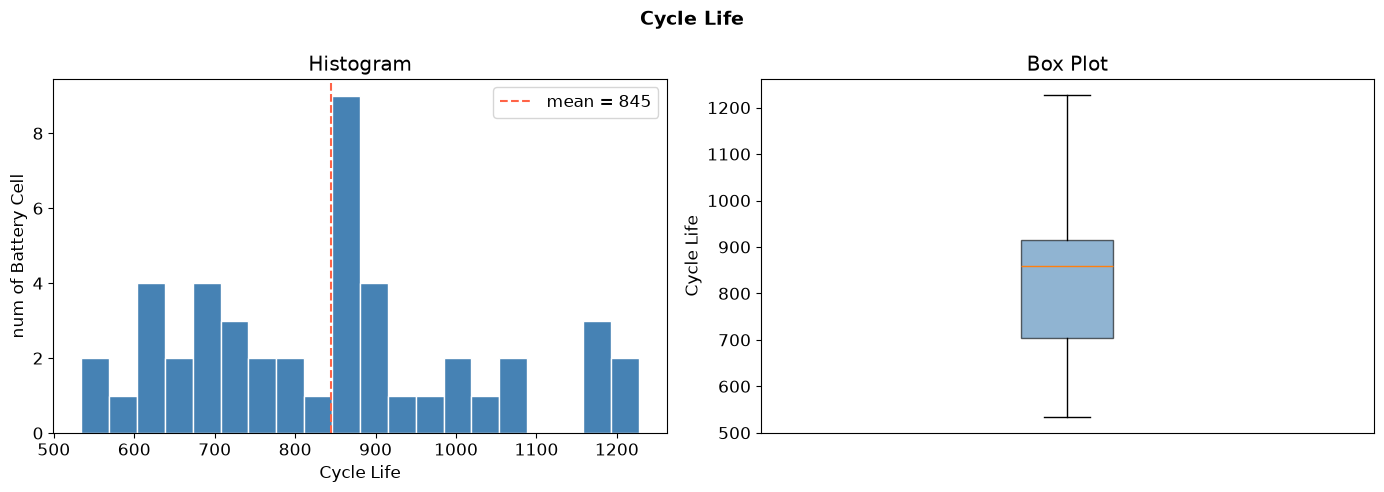

count      46.0
mean      844.7
std       184.6
min       534.0
25%       703.2
50%       858.5
75%       914.2
max      1227.0
Name: cycle_life, dtype: float64


In [14]:
cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(cycle_life_df['cycle_life'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('num of Battery Cell')
axes[0].axvline(cycle_life_df['cycle_life'].mean(), color='tomato', linestyle='--',
                label=f"mean = {cycle_life_df['cycle_life'].mean():.0f}")
axes[0].legend()

# Box Plot
axes[1].boxplot(cycle_life_df['cycle_life'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([])

plt.suptitle('Cycle Life', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(cycle_life_df['cycle_life'].describe().round(1))

[describe] 
- 배터리 평균 수명 약 845 사이클 (단명 534 ~ 장수 1227)
- 평균 vs 중앙값 차이 없음 (데이터 왜곡/편향 적은 편) 
- IQR 통해 절반의 배터리가 703 ~ 914 범위에 집중 

[plot]
- Histogram : 845 근처에 가장 몰려 있고 600대와 1,200대에 일부 분포. 완전한 정규분포는 아님 
- Box plot : 
    - Upper whisker = |75%(914) - max(1227)| = 313
    - Lower whisker = |25%(703) - min(534) | = 169
- Upper가 큼 -> 장수 배터리의 수명 편차가 더 큼 -> 좋은 충전 조건을 만나면 수명이 크게 늘어날 수 있지만, 그 폭이 불규칙함  
- Lower는 상대적으로 짧음 -> 단명 배터리가 534~703 구간에 비교적 일정하게 분포 -> 나쁜 충전 조건에서는 수명이 어느 정도 예측 가능한 범위로 떨어질 수 있음 

[to modeling]
- 수명이 긴 배터리일수록 예측 난이도 있음 
- residual 분석을 함께 진행하는 것도 필요할 수 있음 

### 2. 열화 곡선 - 방전 용량(QD) 감소 패턴

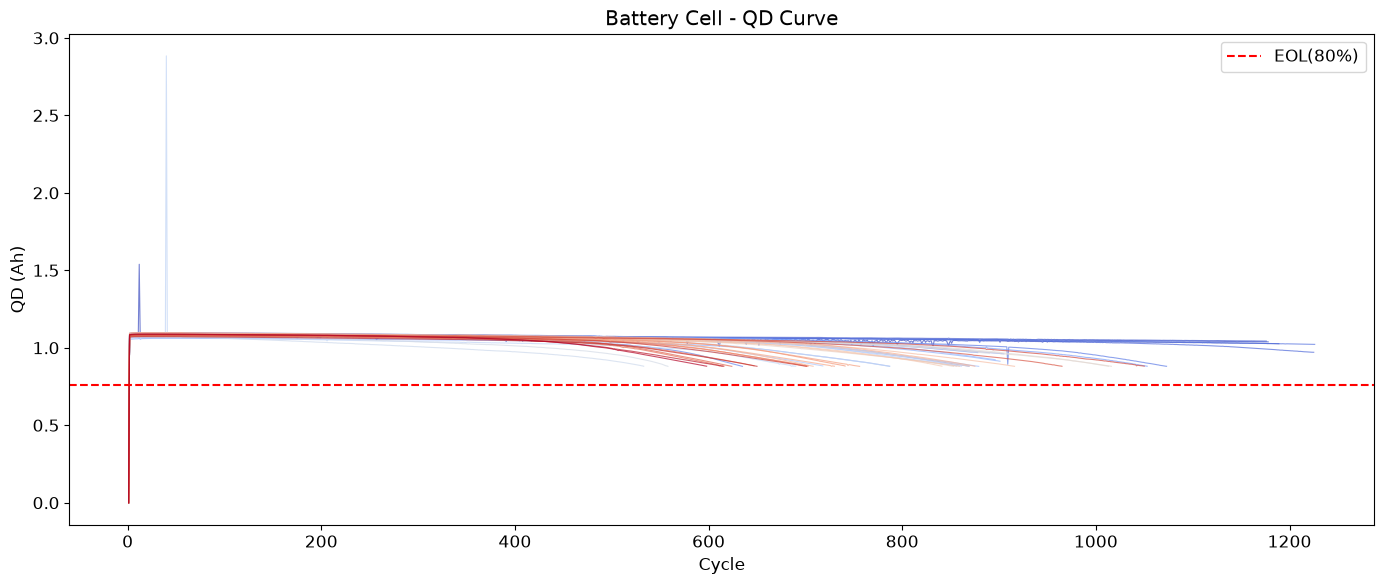

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df['cell_id'].unique()
colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df[df['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
ax.axhline(y=0.88 * nominal,  # ~80% of nominal ≈ 1.1Ah
           color='red', linestyle='--', linewidth=1.5, label='EOL(80%)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve')
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- 초기 이상값 스파이크 (cycle 0 ~ 50 구간) : 정상적인 배터리 용량을 벗어나므로, outlier filtering 고려 대상 
- 열화 패턴 : 대부분의 셀이 약 1.1Ah에서 시작해 사이클이 늘어날수록 원만하게 감소함. 논문에서 언급된 용량 열화(Capacity Fade) 곡선 형태 확인됨 
- 색상 분포 : 파란색은 장수 배터리, 빨간색은 단명 배터리로 구분됨. 사이클 600 이후에 파란색이 높게 유지되는 것으로 보임 

공칭 용량(nominal) : 1.0796 Ah
필터 범위          : 0.8637 ~ 1.2956 Ah
제거된 행 수       : 48 (0.12%)


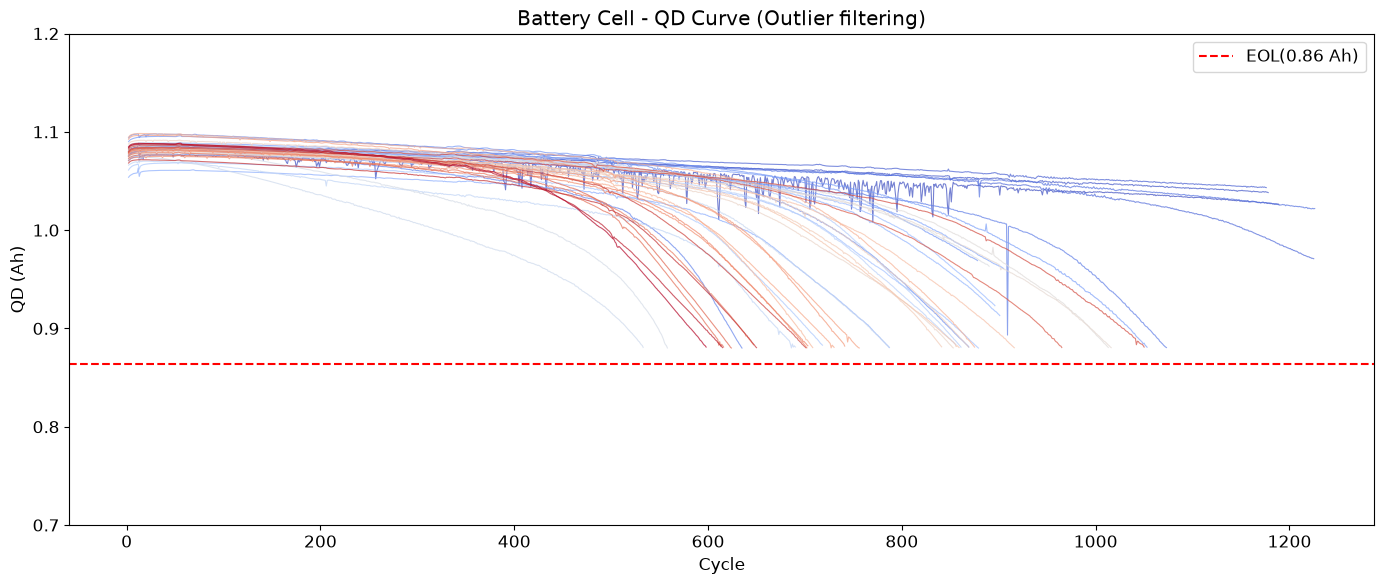

In [16]:
# Outlier 필터링 후 열화 곡선 

# 1. 정상 용량 범위 정의
nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
lower   = nominal * 0.80
upper   = nominal * 1.20

print(f"공칭 용량(nominal) : {nominal:.4f} Ah")
print(f"필터 범위          : {lower:.4f} ~ {upper:.4f} Ah")

# 2. 필터링
df_clean = df[df['QD'].between(lower, upper)].copy()
print(f"제거된 행 수       : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

# 3. 시각화
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df_clean['cell_id'].unique()
colors   = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df_clean[df_clean['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'],
            color=colors[i], linewidth=0.8, alpha=0.7)

ax.axhline(y=nominal * 0.8, color='red', linestyle='--',
           linewidth=1.5, label=f'EOL({nominal*0.8:.2f} Ah)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve (Outlier filtering)')
ax.set_ylim(0.7, 1.2)
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- cycle  1 ~  50 : 모든 셀이 1.06~1.10Ah 범위에서 시작하며 초기 용량이 매우 균일함 -> 셀 간 초기 상태 차이 거의 없음 
- cycle 50 ~ 400 : 회색 계열 셀들이 다른 셀보다 빠르게 하강 
- cycle 400 ~    : 
    - 붉은 계열 : cycle 600 부근에서 EOL 기준선에 도달하며 조기 종료 
    - 파란 계열 : cycle 1,000 이후에도 1.0Ah 수준을 유지하며 장수 

[to modeling]
- 초기 구간에는 모든 선이 거의 겹쳐 보임 -> QD 값만으로는 차이를 확인할 수 없음 -> ΔQ(V) 확인 필요 

### 3. 내부 저항(IR) 변화 - 열화 지표

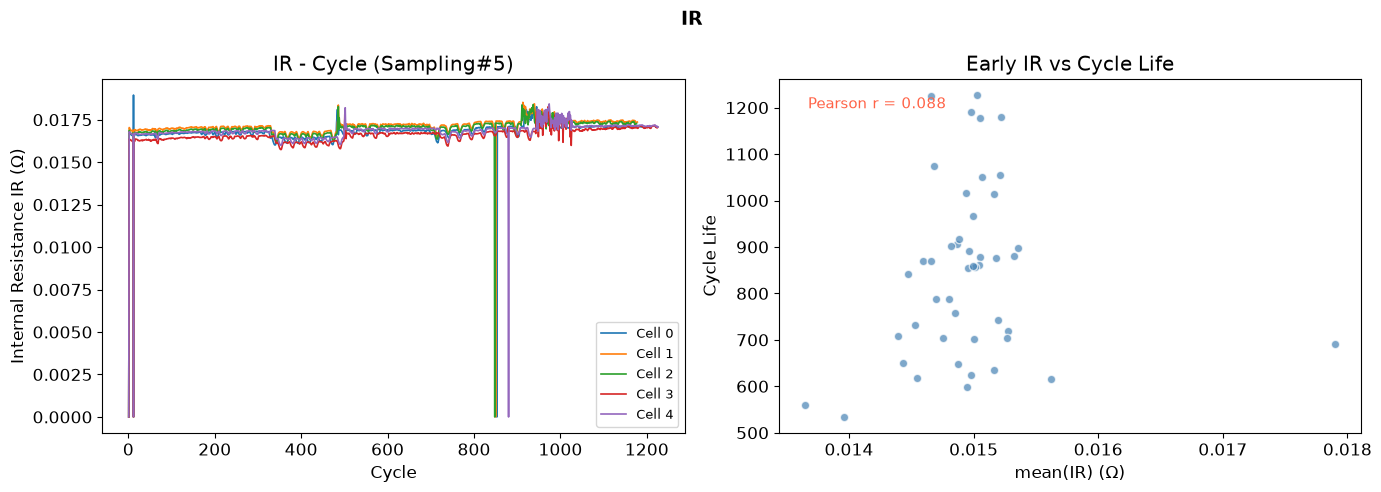

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사이클에 따른 IR 변화 (샘플 5개)
sample_cells = cell_ids[:5]
for cid in sample_cells:
    sub = df[df['cell_id'] == cid]
    axes[0].plot(sub['cycle'], sub['IR'], label=f'Cell {cid}', linewidth=1.2)

axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Internal Resistance IR (Ω)')
axes[0].set_title('IR - Cycle (Sampling#5)')
axes[0].legend(fontsize=9)

# cycle_life vs 초기 IR 상관관계
early_ir = df[df['cycle'] <= 10].groupby('cell_id')['IR'].mean().reset_index()
early_ir.columns = ['cell_id', 'early_IR']
merged = cycle_life_df.merge(early_ir, on='cell_id')

axes[1].scatter(merged['early_IR'], merged['cycle_life'],
                alpha=0.7, color='steelblue', edgecolors='white')
axes[1].set_xlabel('mean(IR) (Ω)')
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Early IR vs Cycle Life')

corr = merged['early_IR'].corr(merged['cycle_life'])
axes[1].text(0.05, 0.95, f'Pearson r = {corr:.3f}',
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', color='tomato')

plt.suptitle('IR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[plot] - Sampling
- 내부저항(IR)이 전체 구간에서 평탄함. 배터리가 열화될수록 IR이 증가해야 하는데 해당 샘플에서는 확인되지 않음 
    - 샘플링 배터리는 IR 변화가 용량 변화에 비해 상대적으로 적음 -> 흑연 음극 구조 특징 
    - 사이클 800~900 부근의 스파이크는 측정 노이즈 또는 셀 교체 시점으로 해석 가능 

[plot] - correlation 
- 상관계수가 0.088이고, scatter 분포를 통해 상관관계 전혀 없음 

[to modeling]
- IR 단독으로 target variable 설명할 수 없음 
- IR 변화율(ΔIR) 또는 다른 변수와의 조합/비교 통한 파생변수 고민 

### 4. 충전 정책(C-rate)과 수명의 관계

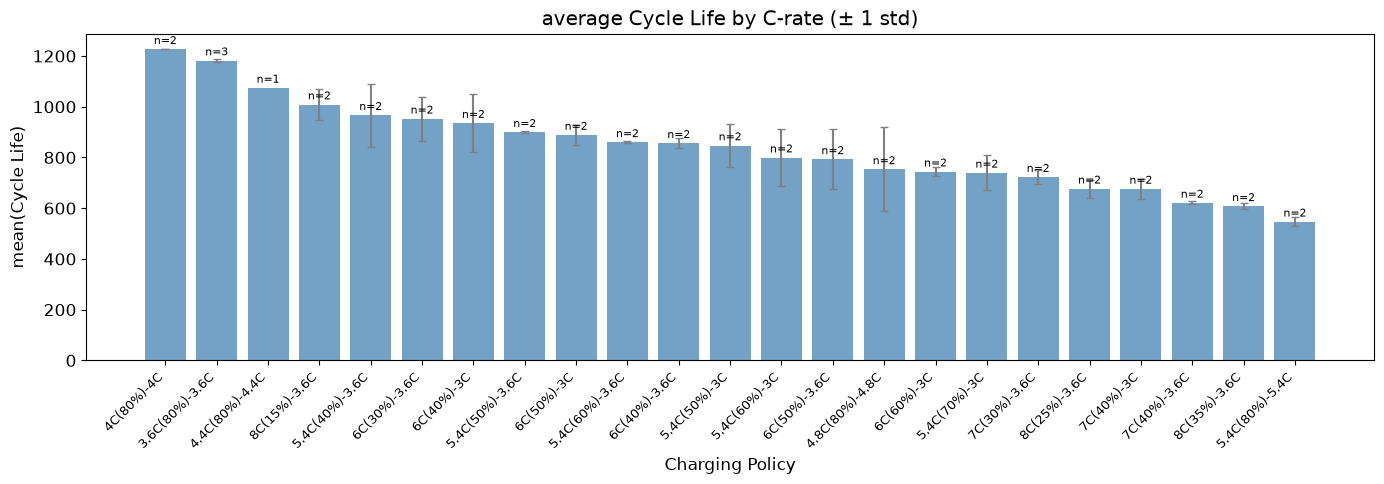

In [18]:
policy_life = cycle_life_df.groupby('charging_policy')['cycle_life'].agg(['mean', 'std', 'count'])
policy_life = policy_life.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(policy_life))
bars = ax.bar(x, policy_life['mean'], 
               yerr=policy_life['std'],
               color='steelblue', alpha=0.75,
               error_kw=dict(ecolor='gray', capsize=3))
ax.set_xticks(x)
ax.set_xticklabels(policy_life.index, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Charging Policy')
ax.set_ylabel('mean(Cycle Life)')
ax.set_title('average Cycle Life by C-rate (± 1 std)')

for bar, (_, row) in zip(bars, policy_life.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

[remark] C-rate : 배터리 용량 대비 총전/방전 속도를 나타내는 단위 
- C-rate 
    - `1C` : 1시간 만에 완충
    - `2C` : 30분 만에 완충 
    - `4C` : 15분 만에 완충 (숫자가 클수록 빠름) 
- `4C(80%)-4C`
    - `4C` : 1단계. 0% -> 80%까지 4C 속도로 충전 
    - `(80%)` : 전환 기준. 용량 80% 도달 시 속도 변경 
    - `4C` : 2단계. 나머지 20%는 4C 속도로 충전 
- 정책 비교 
    - `4C(80%)-4C` : 처음부터 끝까지 빠르게 
    - `4C(80%)-3.6C` : 2단계만 살짝 천천히 
    - `5.4C(80%)-5.4C` : 처음부터 끝까지 매우 빠르게 -> 수명 최단

[plot]
- 왼쪽(장수)에서 오른쪽(단명)으로 갈수록 C-rate 숫자가 커지는 경향 
    - 상위 구간 (cycle 1000~1200) : `4C(80%)-4C`, `3.6C(80%)-3.6C`
    - 중위 구간 (cycle 800~900)   : `6C(40%)-3C`, `5.4C(50%)-3.6C`
    - 하위 구간 (cycle 500~600)   : `8C(35%)-3.6C`, `5.4C(80%)-5.4C`
    - 낮은 C-rate은 천천히 충전할수록 수명이 길고, 높은 C-rate로 빠르게 충전할수록 수명이 짧음 
    - Notion > Domain : 빠른 충전이 음극 팽창/수축을 가속화한다는 내용 확인 
- 2단계 충전 전략 영향도 : `8C(15%)-3.6C` vs `8C(25%)-3.6C` 
    - 그래프에서는 전환 기준을 어떻게 가져가느냐에 따라 배터리 수명에 영향을 주는 것으로 보임 
    - 그러나 샘플이 정책당 2건 밖에 되지 않으므로 "경향성" 수준으로 해석해야 함 

[to modeling]
- 충전 정책은 배터리 수명에 영향을 미치고 있음 
- 특정 정책에서는 편차가 존재하므로 추가 변수 고려 필요

### 5. 상관관계 히트맵

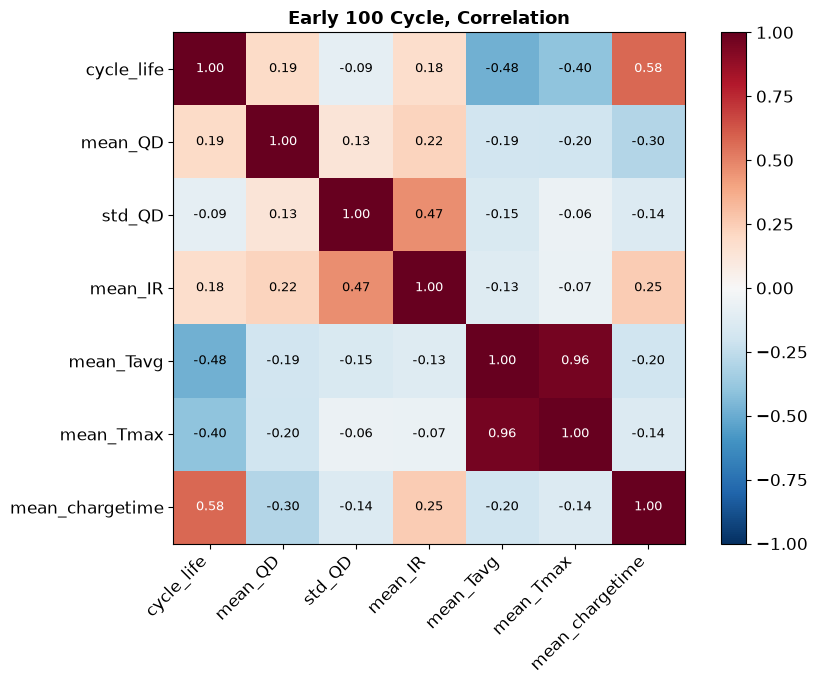


[cycle_life Corr Rank]
mean_chargetime    0.577
mean_Tavg         -0.482
mean_Tmax         -0.404
mean_QD            0.193
mean_IR            0.177
std_QD            -0.090
Name: cycle_life, dtype: float64


In [19]:
# 배터리별 초기 100 사이클 평균 집계
early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life   = ('cycle_life', 'first'),
    mean_QD      = ('QD', 'mean'),
    std_QD       = ('QD', 'std'),
    mean_IR      = ('IR', 'mean'),
    mean_Tavg    = ('Tavg', 'mean'),
    mean_Tmax    = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index(drop=True)

corr_matrix = early.corr()

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_title('Early 100 Cycle, Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[cycle_life Corr Rank]")
print(corr_matrix['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))

[correlation]
- `mean_chargetime` : 충전 시간이 길수록 수명이 길어짐 -> C-rate과 직결. 천천히 충전(긴 충전시간) = 낮은 C-rate = 긴 수명으로 앞에서 확인 
- `mean_Tavg`, `mean_Tmax` : 온도가 높을수록 수명이 짧아짐. 빠른 충전(높은 C-rate)이 발열을 유발하고 이것이 열화를 가속화하는 인과관계 확인 
- `mean_Tavg` vs `mean_Tmax` : 다중공선성(0.96) 

[to modeling]
- 선형 관계 일부분 확인 가능 
- 비선형 패턴까지 추가 확인 필요

---
## 5. 다음 단계 안내

이 Scratch 노트북에서 확인한 내용을 바탕으로 아래 작업을 수행하세요.

**DAY 1 - EDA**
1. `cycle_life` 분포는 어떻게 생겼는가?
2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?
3. `ΔQ(V)` 곡선 - 초기 사이클에서 차이가 보이는가?
4. 충전 조건 (C-rate)과 수명의 관계는?
5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

**DAY 2 - 모델링**
- Regression : `cycle_life` 수치 예측 (초기 100 사이클)
- Classification : 장/단 수명 이진 분류 (초기 5 사이클)

(**Hint**) : `ΔQ(V)` 곡선은 `cycles[n]['Qdlin']`을 사용하여 계산합니다.

In [20]:
#Q1 Cycle Life Distribution

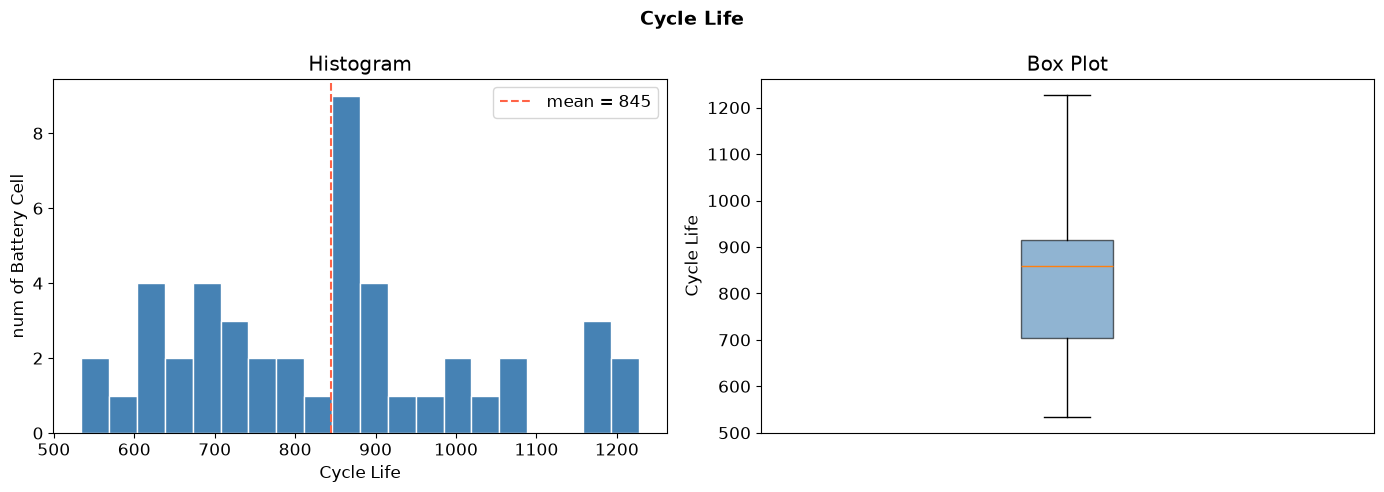

count      46.0
mean      844.7
std       184.6
min       534.0
25%       703.2
50%       858.5
75%       914.2
max      1227.0
Name: cycle_life, dtype: float64


In [21]:
cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(cycle_life_df['cycle_life'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('num of Battery Cell')
axes[0].axvline(cycle_life_df['cycle_life'].mean(), color='tomato', linestyle='--',
                label=f"mean = {cycle_life_df['cycle_life'].mean():.0f}")
axes[0].legend()

# Box Plot
axes[1].boxplot(cycle_life_df['cycle_life'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([])

plt.suptitle('Cycle Life', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(cycle_life_df['cycle_life'].describe().round(1))

In [22]:
# Batch 1, 2, 3을 동일한 cycle-level 형식으로 변환하여 통합
# 확인된 구조: 모든 batch는 동일한 summary 필드를 가지지만,
# Batch 2의 8개 셀과 Batch 3의 2개 셀은 cycle_life가 NaN입니다.
import gc

BATCH_FILES = {
    'Batch 1': '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    'Batch 2': '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    'Batch 3': '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}

SUMMARY_COLUMNS = {
    'QDischarge': 'QD',
    'QCharge': 'QC',
    'IR': 'IR',
    'Tmax': 'Tmax',
    'Tavg': 'Tavg',
    'Tmin': 'Tmin',
    'chargetime': 'chargetime',
}

def normalize_batch(raw_batch):
    """mat73의 dict-of-lists 구조를 셀별 list-of-dicts로 변환합니다."""
    if not isinstance(raw_batch, dict):
        return list(raw_batch)

    keys = list(raw_batch.keys())
    field_lengths = {key: len(raw_batch[key]) for key in keys}
    if len(set(field_lengths.values())) != 1:
        raise ValueError(f'batch 필드별 셀 수가 다릅니다: {field_lengths}')

    n_cells = next(iter(field_lengths.values()))
    return [{key: raw_batch[key][i] for key in keys} for i in range(n_cells)]

def safe_cycle_life(value):
    """유효한 cycle_life는 float, NaN/빈 값은 np.nan으로 반환합니다."""
    try:
        value = np.asarray(value, dtype=float).squeeze()
        if value.size == 1 and np.isfinite(value):
            return float(value)
    except (TypeError, ValueError):
        pass
    return np.nan

def extract_batch_summary(cells, batch_name, global_id_start=0):
    """한 batch를 기존 df와 같은 cycle-level DataFrame으로 변환합니다."""
    frames = []

    for local_cell_id, cell in enumerate(cells):
        summary = cell['summary']
        arrays = {
            output_name: np.asarray(summary[input_name], dtype=float).ravel()
            for input_name, output_name in SUMMARY_COLUMNS.items()
        }

        # 실제 cycle 번호가 있으면 사용하고, 없으면 1부터 생성합니다.
        if 'cycle' in summary:
            cycle = np.asarray(summary['cycle'], dtype=float).ravel()
        else:
            cycle = np.arange(1, len(arrays['QD']) + 1, dtype=float)

        lengths = {'cycle': len(cycle), **{k: len(v) for k, v in arrays.items()}}
        n_cycles = min(lengths.values())
        if len(set(lengths.values())) != 1:
            print(f'주의: {batch_name} cell {local_cell_id} 필드 길이 차이 {lengths}; '
                  f'앞의 {n_cycles}개 cycle만 사용합니다.')

        cycle_life = safe_cycle_life(cell.get('cycle_life'))
        policy = cell.get('policy_readable') or cell.get('policy') or 'unknown'
        global_cell_id = global_id_start + local_cell_id

        cell_df = pd.DataFrame({
            'batch': batch_name,
            'cell_id': global_cell_id,
            'local_cell_id': local_cell_id,
            'cell_uid': f'{batch_name}-cell-{local_cell_id:02d}',
            'cycle': cycle[:n_cycles],
            'cycle_life': cycle_life,
            'has_cycle_life': np.isfinite(cycle_life),
            'charging_policy': str(policy),
            **{name: values[:n_cycles] for name, values in arrays.items()},
        })
        frames.append(cell_df)

    return pd.concat(frames, ignore_index=True)

batch_frames = {}
global_id_start = 0

for batch_name, filename in BATCH_FILES.items():
    print(f'[{batch_name}] {filename}')

    if batch_name == 'Batch 1':
        # 위쪽 셀에서 이미 변환된 batch를 재사용합니다.
        cells = batch
        loaded_mat = None
    else:
        loaded_mat = load_mat(os.path.join(DATA_DIR, filename))
        cells = normalize_batch(loaded_mat['batch'])

    batch_df = extract_batch_summary(cells, batch_name, global_id_start)
    batch_frames[batch_name] = batch_df

    n_cells = len(cells)
    missing_life = batch_df.loc[~batch_df.has_cycle_life, 'cell_id'].nunique()
    print(f'  cells={n_cells}, rows={len(batch_df):,}, '
          f'missing cycle_life cells={missing_life}')
    global_id_start += n_cells

    if batch_name != 'Batch 1':
        del cells, loaded_mat
        gc.collect()

# 배치별 DataFrame과 최종 통합 DataFrame
df_batch1 = batch_frames['Batch 1']
df_batch2 = batch_frames['Batch 2']
df_batch3 = batch_frames['Batch 3']
df_all = pd.concat([df_batch1, df_batch2, df_batch3], ignore_index=True)

# 정수처럼 보이는 값은 nullable integer로 관리합니다(NaN 허용).
df_all['cycle'] = df_all['cycle'].round().astype('Int64')
df_all['cycle_life'] = df_all['cycle_life'].round().astype('Int64')

print('\n통합 완료')
print(f'df_all shape: {df_all.shape}')
print(f'전체 셀 수: {df_all.cell_id.nunique()}')
# 셀별 수명 통계는 cycle 행 수에 의해 가중되지 않도록 셀당 한 행에서 계산합니다.
cell_overview = (df_all.drop_duplicates('cell_id')
                 [['batch', 'cell_id', 'cycle_life', 'has_cycle_life']])
batch_overview = cell_overview.groupby('batch', observed=True).agg(
    cells=('cell_id', 'size'),
    valid_cycle_life_cells=('has_cycle_life', 'sum'),
    min_cycle_life=('cycle_life', 'min'),
    mean_cycle_life=('cycle_life', 'mean'),
    max_cycle_life=('cycle_life', 'max'),
)
batch_overview['missing_cycle_life_cells'] = (
    batch_overview['cells'] - batch_overview['valid_cycle_life_cells'])
batch_overview['rows'] = df_all.groupby('batch', observed=True).size()
display(batch_overview[['cells', 'rows', 'valid_cycle_life_cells',
                        'missing_cycle_life_cells', 'min_cycle_life',
                        'mean_cycle_life', 'max_cycle_life']].round(1))

# Cycle Life 분석에서는 아래처럼 결측 target 셀을 제외합니다.
cycle_life_all = (df_all[df_all.has_cycle_life]
                  .drop_duplicates('cell_id')
                  [['batch', 'cell_id', 'local_cell_id', 'cell_uid',
                    'cycle_life', 'charging_policy']]
                  .reset_index(drop=True))

display(df_all.head())


[Batch 1] 2017-05-12_batchdata_updated_struct_errorcorrect.mat
  cells=46, rows=38,811, missing cycle_life cells=0
[Batch 2] 2018-02-20_batchdata_updated_struct_errorcorrect.mat


로드 완료 (MATLAB v7.3 / HDF5 형식)
  cells=47, rows=26,904, missing cycle_life cells=8


[Batch 3] 2018-04-12_batchdata_updated_struct_errorcorrect.mat


로드 완료 (MATLAB v7.3 / HDF5 형식)
  cells=46, rows=51,007, missing cycle_life cells=2



통합 완료
df_all shape: (116722, 15)
전체 셀 수: 139


,cells,rows,valid_cycle_life_cells,missing_cycle_life_cells,min_cycle_life,mean_cycle_life,max_cycle_life
batch,,,,,,,
Batch 1,46,38811,46,0,534,844.7,1227
Batch 2,47,26904,39,8,392,565.7,1186
Batch 3,46,51007,44,2,541,1059.7,1935


,batch,cell_id,local_cell_id,cell_uid,cycle,cycle_life,has_cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,Batch 1,0,0,Batch 1-cell-00,1,1190,True,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Batch 1,0,0,Batch 1-cell-00,2,1190,True,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,Batch 1,0,0,Batch 1-cell-00,3,1190,True,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,Batch 1,0,0,Batch 1-cell-00,4,1190,True,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,Batch 1,0,0,Batch 1-cell-00,5,1190,True,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


## 통합 데이터 분석 준비
통합 셀을 먼저 실행하세요. 원본 세 배치의 단순 통합 기준이며, 연속 실험 병합이나 논문 전처리는 적용하지 않습니다.

In [23]:
import re
import h5py
from scipy import stats
from IPython.display import display

assert 'df_all' in globals(), '위의 Batch 1–3 통합 셀을 먼저 실행하세요.'
eda = df_all.copy()
for col in ['cycle', 'cycle_life', 'QD', 'QC', 'IR', 'Tmax', 'Tavg', 'Tmin', 'chargetime']:
    eda[col] = pd.to_numeric(eda[col], errors='coerce').astype(float)
cell_meta = eda.drop_duplicates('cell_id')[['batch','cell_id','local_cell_id','cell_uid','cycle_life','charging_policy']].copy()
cell_meta['life_group'] = np.select([cell_meta.cycle_life < 500, cell_meta.cycle_life > 1000],
                                   ['short (<500)', 'long (>1000)'], default='middle')
cell_meta.loc[cell_meta.cycle_life.isna(), 'life_group'] = 'unknown'
colors = {'short (<500)':'tomato','long (>1000)':'royalblue','middle':'gray','unknown':'silver'}

# 유효 초기 QD 중앙값으로 기준 용량을 구함. EOL 이하 관측은 제거하지 않음.
baseline = (eda[eda.cycle.between(2,10) & eda.QD.between(.5,2)]
            .groupby('cell_id').QD.median())
eda['baseline_QD'] = eda.cell_id.map(baseline)
eda['valid_QD'] = np.isfinite(eda.QD) & (eda.QD > 0) & (eda.QD <= 1.3*eda.baseline_QD)
early = eda[eda.cycle.between(2,100)].copy()
early.loc[~early.valid_QD, 'QD'] = np.nan
for col in ['IR','Tavg','Tmax','chargetime']:
    early.loc[early[col] <= 0, col] = np.nan
early_features = early.groupby('cell_id').agg(
    early_QD_mean=('QD','mean'), early_QD_std=('QD','std'), early_IR_mean=('IR','mean'),
    early_Tavg_mean=('Tavg','mean'), early_Tmax_mean=('Tmax','mean'),
    early_chargetime_mean=('chargetime','mean'), early_cycles=('cycle','nunique')).reset_index()
print(f'통합: {len(cell_meta)} cells; 유효 수명: {cell_meta.cycle_life.notna().sum()} cells')


# PPT 내보내기: 16:9, PNG 300dpi (4800×2700) + 확대 가능한 PDF
from pathlib import Path
from matplotlib import font_manager
PPT_DIR = Path.cwd() / 'day1_ppt_figures'
PPT_DIR.mkdir(exist_ok=True)
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
korean_font = next((n for n in ['AppleGothic','NanumGothic','Nanum Gothic','Malgun Gothic'] if n in available_fonts), None)
if korean_font is None:
    raise RuntimeError('한글 폰트를 설치한 후 다시 실행하세요.')
plt.rcParams.update({'font.family':korean_font,'axes.unicode_minus':False,'font.size':13,
                     'axes.titlesize':17,'axes.labelsize':14,'legend.fontsize':11})
figure_number=0
text_ko={
 'short (<500)':'단수명 (<500)', 'long (>1000)':'장수명 (>1,000)',
 'middle':'중간 수명', 'unknown':'수명 미기록',
 'Cycle life':'수명 (사이클)', 'Cycle':'사이클', 'Number of cells':'셀 수',
 'Voltage (V)':'전압 (V)', 'Time (min)':'시간 (분)',
 'Batch 1–3: cycle life distribution':'세 배치 통합 수명 분포',
 'Distribution by batch':'배치별 수명 분포',
 'Smoothed discharge capacity (black = knee candidate)':'방전 용량 변화 (검정 점: Knee 후보)',
 'Normalized capacity':'초기 용량 대비 방전 용량',
 '80% of initial QD':'초기 용량의 80%', 'QD / initial QD':'초기 용량 대비 QD',
 'Short vs long: median and IQR':'장·단수명 비교: 중앙값과 사분위 범위',
 'Early ΔQ feature vs life':'초기 ΔQ 피쳐와 수명',
 'log10 variance(ΔQ)':'ΔQ 분산의 상용로그',
 'Measured early mean charging C-rate':'초기 실측 평균 충전 C-rate',
 'Fast charging vs life':'충전 속도와 수명',
 'Early capacity loss / cycle (Ah)':'사이클당 초기 용량 감소 (Ah)',
 'Charging vs early degradation':'충전 속도와 초기 열화',
 'Charging current (A)':'충전 전류 (A)', 'Cycle 10 current examples':'10번째 사이클 충전 전류 예시',
 'Top early features: Pearson correlation':'초기 주요 피쳐의 Pearson 상관관계',
 'Early feature correlations':'초기 피쳐 간 상관관계',
}
def save_ppt(fig,name):
    from matplotlib.text import Text
    for artist in fig.findobj(Text):
        t=artist.get_text()
        for en,ko in text_ko.items(): t=t.replace(en,ko)
        artist.set_text(t)
    fig.set_size_inches(16,9)
    fig.tight_layout(pad=2)
    fig.savefig(PPT_DIR / (name+'.png'),dpi=300,facecolor='white')
    fig.savefig(PPT_DIR / (name+'.pdf'),facecolor='white')
    plt.show()
def export_current():
    global figure_number
    figure_number+=1
    save_ppt(plt.gcf(),f'{figure_number:02d}_통합분석')


통합: 139 cells; 유효 수명: 129 cells


## 1. Cycle Life 분포·장수명/단수명 비율·이상치

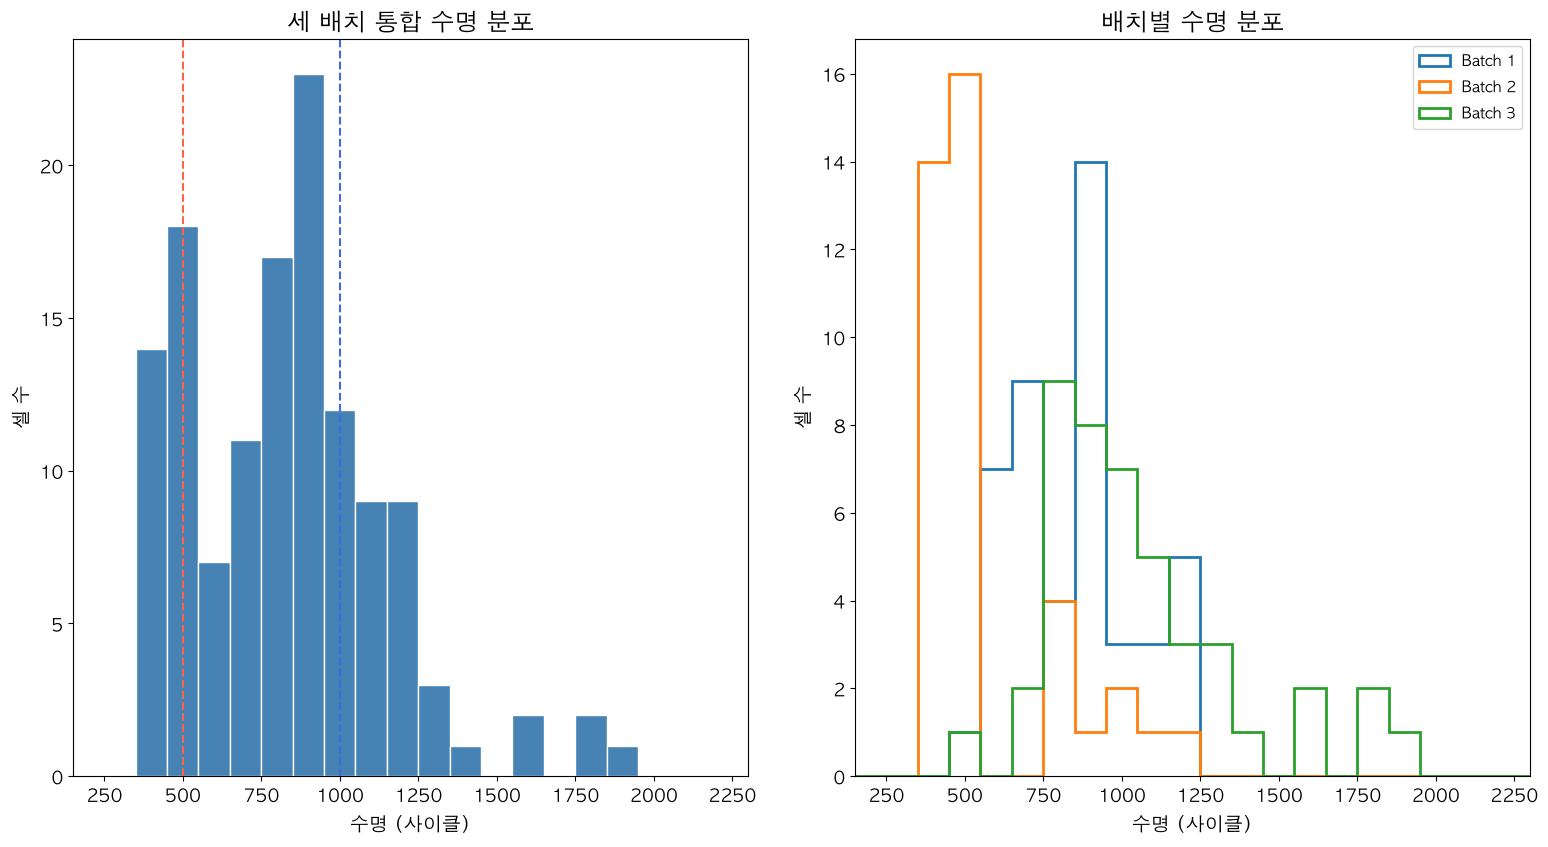

실제 범위: 392–1935; 표시 범위 밖 셀: 0


,cells,ratio_%
life_group,,
short (<500),28,21.71
middle,65,50.39
long (>1000),36,27.91


,cycle_life
count,129.0
mean,833.7
std,315.0
min,392.0
25%,559.0
50%,828.0
75%,1017.0
max,1935.0


IQR 범위: -128.0–1704.0


,batch,cell_id,local_cell_id,cell_uid,cycle_life,charging_policy,life_group,early_QD_mean,early_QD_std,early_IR_mean,early_Tavg_mean,early_Tmax_mean,early_chargetime_mean,early_cycles,IQR_low_outlier,IQR_high_outlier,early_IR_mean_vs_batch_median,early_Tavg_mean_vs_batch_median,early_chargetime_mean_vs_batch_median
138,Batch 3,138,45,Batch 3-cell-45,1801.0,4.8C(80%)-4.8C-newstructure,long (>1000),1.071466,0.000460,0.015619,32.725964,34.681773,11.038588,99,False,True,0.000246,-1.434748,0.995262
100,Batch 3,100,7,Batch 3-cell-07,1836.0,4.8C(80%)-4.8C-newstructure,long (>1000),1.070177,0.000632,0.015428,32.796945,34.274779,11.040740,99,False,True,0.000056,-1.363766,0.997415
131,Batch 3,131,38,Batch 3-cell-38,1935.0,5C(67%)-4C-newstructure,long (>1000),1.071983,0.000460,0.015836,34.745836,37.739091,10.043708,99,False,True,0.000463,0.585125,0.000382


단수명 셀: 정책, 온도, 저항, 충전시간을 같은 batch 중앙값과 비교


,batch,cell_id,local_cell_id,cell_uid,cycle_life,charging_policy,life_group,early_QD_mean,early_QD_std,early_IR_mean,early_Tavg_mean,early_Tmax_mean,early_chargetime_mean,early_cycles,IQR_low_outlier,IQR_high_outlier,early_IR_mean_vs_batch_median,early_Tavg_mean_vs_batch_median,early_chargetime_mean_vs_batch_median
65,Batch 2,65,19,Batch 2-cell-19,392.0,6C(60%)-3C,short (<500),1.0948,0.0029,0.0167,32.7701,36.5488,10.1738,99,False,False,0.0001,-0.2781,-0.0075
52,Batch 2,52,6,Batch 2-cell-06,393.0,3.6C(9%)-5C,short (<500),1.0930,0.0029,0.0160,33.8190,39.7971,10.1793,99,False,False,-0.0006,0.7708,-0.0019
61,Batch 2,61,15,Batch 2-cell-15,396.0,3.6C(9%)-5C,short (<500),1.0750,0.0030,0.0163,32.8627,36.0727,10.1731,99,False,False,-0.0003,-0.1855,-0.0082
67,Batch 2,67,21,Batch 2-cell-21,408.0,6C(60%)-3C,short (<500),1.1011,0.0111,0.0172,33.6012,38.6608,10.1747,99,False,False,0.0006,0.5530,-0.0065
76,Batch 2,76,30,Batch 2-cell-30,412.0,5.6C(26%)-4.5C,short (<500),1.0930,0.0035,0.0169,33.8118,37.3431,49.8294,99,False,False,0.0003,0.7636,39.6482
51,Batch 2,51,5,Batch 2-cell-05,416.0,3.6C(30%)-6C,short (<500),1.0879,0.0130,0.0153,33.0131,37.6509,10.1987,99,False,False,-0.0013,-0.0351,0.0175
48,Batch 2,48,2,Batch 2-cell-02,424.0,5.2C(50%)-4.25C,short (<500),1.0747,0.0113,0.0165,33.1757,37.4291,10.1750,99,False,False,-0.0002,0.1275,-0.0062
77,Batch 2,77,31,Batch 2-cell-31,425.0,5.6C(26%)-4.5C,short (<500),1.0999,0.0018,0.0163,33.3759,35.6564,10.1945,99,False,False,-0.0003,0.3276,0.0133
60,Batch 2,60,14,Batch 2-cell-14,426.0,3.6C(30%)-6C,short (<500),1.0793,0.0035,0.0163,32.1239,35.2005,49.8795,99,False,False,-0.0004,-0.9243,39.6983
74,Batch 2,74,28,Batch 2-cell-28,437.0,4.8C(80%)-4.8C,short (<500),1.0951,0.0025,0.0163,32.1439,35.3349,49.8054,99,False,False,-0.0004,-0.9043,39.6242


짧은 수명과 IQR 이상치는 다른 기준입니다. 측정값 비교는 원인 후보이며 인과 증거는 아닙니다.


life_group,short (<500),middle,long (>1000)
batch,,,
Batch 1,0,36,10
Batch 2,28,8,3
Batch 3,0,21,23


life_group,short (<500),middle,long (>1000)
batch,,,
Batch 1,0.00,78.26,21.74
Batch 2,71.79,20.51,7.69
Batch 3,0.00,47.73,52.27


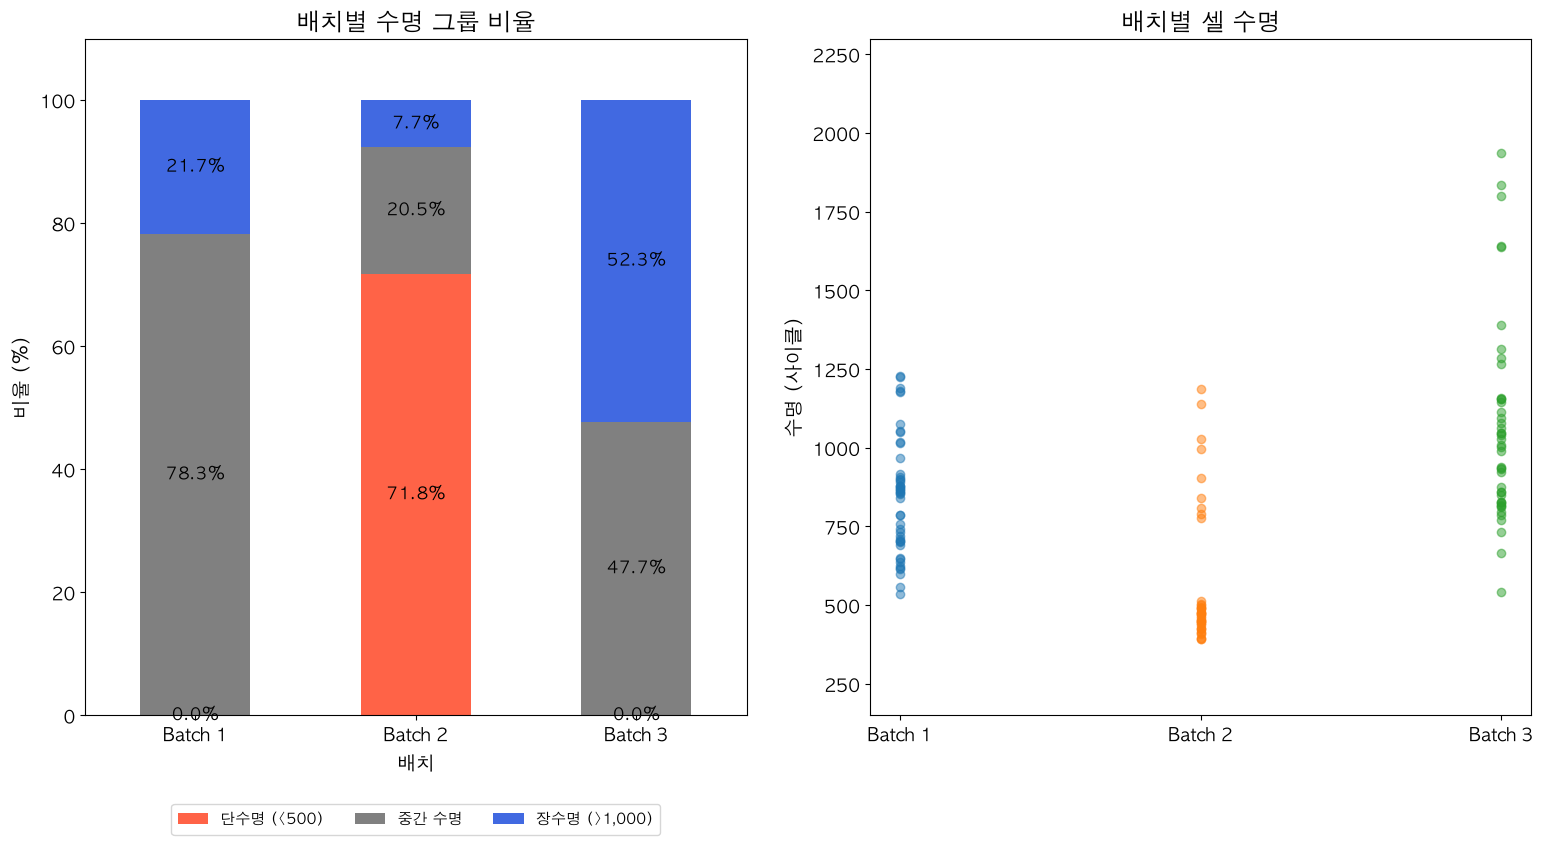

In [24]:
life = cell_meta.cycle_life.dropna()
# 150~2300을 표시 범위로 지정하되 실제 범위는 데이터 그대로 보고함
edges = np.r_[np.arange(150,2300,100),2300]
fig, axes = plt.subplots(1,2,figsize=(15,5))
axes[0].hist(life,bins=edges,color='steelblue',edgecolor='white')
axes[0].set(xlim=(150,2300),xlabel='Cycle life',ylabel='Number of cells',title='Batch 1–3: cycle life distribution')
for threshold,color in [(500,'tomato'),(1000,'royalblue')]: axes[0].axvline(threshold,color=color,ls='--')
for name,g in cell_meta.groupby('batch'):
    axes[1].hist(g.cycle_life.dropna(),bins=edges,histtype='step',lw=2,label=name)
axes[1].set(xlim=(150,2300),xlabel='Cycle life',ylabel='Number of cells',title='Distribution by batch')
axes[1].legend(); plt.tight_layout(); export_current()
print(f'실제 범위: {life.min():.0f}–{life.max():.0f}; 표시 범위 밖 셀: {((life<150)|(life>2300)).sum()}')
counts = cell_meta.loc[cell_meta.cycle_life.notna(),'life_group'].value_counts().reindex(
    ['short (<500)','middle','long (>1000)'],fill_value=0)
display(pd.DataFrame({'cells':counts,'ratio_%':100*counts/len(life)}).round(2))
display(life.describe().to_frame('cycle_life').round(1))
lo,hi=life.quantile([.25,.75]); width=hi-lo
diagnosis=cell_meta.merge(early_features,on='cell_id',how='left')
diagnosis['IQR_low_outlier']=diagnosis.cycle_life < lo-1.5*width
diagnosis['IQR_high_outlier']=diagnosis.cycle_life > hi+1.5*width
for c in ['early_IR_mean','early_Tavg_mean','early_chargetime_mean']:
    diagnosis[c+'_vs_batch_median']=diagnosis[c]-diagnosis.groupby('batch')[c].transform('median')
print(f'IQR 범위: {lo-1.5*width:.1f}–{hi+1.5*width:.1f}')
display(diagnosis[diagnosis.IQR_low_outlier | diagnosis.IQR_high_outlier].sort_values('cycle_life'))
print('단수명 셀: 정책, 온도, 저항, 충전시간을 같은 batch 중앙값과 비교')
display(diagnosis[diagnosis.cycle_life<500].sort_values('cycle_life').round(4))
print('짧은 수명과 IQR 이상치는 다른 기준입니다. 측정값 비교는 원인 후보이며 인과 증거는 아닙니다.')


# 배치별 비율: 분모는 각 배치에서 수명이 기록된 셀 수
groups=['short (<500)','middle','long (>1000)']
batch_counts=pd.crosstab(cell_meta.batch,cell_meta.life_group).reindex(columns=groups,fill_value=0)
batch_ratios=batch_counts.div(batch_counts.sum(axis=1),axis=0)*100
display(batch_counts); display(batch_ratios.round(2))
fig,axes=plt.subplots(1,2)
batch_ratios.plot.bar(stacked=True,color=[colors[g] for g in groups],ax=axes[0],rot=0)
axes[0].set(title='배치별 수명 그룹 비율',xlabel='배치',ylabel='비율 (%)',ylim=(0,110))
for container in axes[0].containers: axes[0].bar_label(container,fmt='%.1f%%',label_type='center',fontsize=12)
axes[0].legend(loc='upper center',bbox_to_anchor=(.5,-.12),ncol=3)
for i,(b,g) in enumerate(cell_meta.groupby('batch')):
    axes[1].scatter(np.full(g.cycle_life.notna().sum(),i),g.cycle_life.dropna(),alpha=.5)
axes[1].set_xticks(range(3));axes[1].set_xticklabels(batch_counts.index)
axes[1].set(title='배치별 셀 수명',ylabel='수명 (사이클)',ylim=(150,2300))
save_ppt(fig,'Q1_배치별_수명구성')
batch_ratios.to_csv(PPT_DIR/'Q1_배치별_수명비율.csv',encoding='utf-8-sig')
diagnosis.to_csv(PPT_DIR/'Q1_이상치_진단.csv',index=False,encoding='utf-8-sig')


## 2. QD 열화 곡선·열화 가속·Knee 추정
Knee는 연속된 두 직선 모델의 오차가 가장 작은 지점입니다. 단일 직선 대비 오차 개선과 기울기 가속 조건을 만족할 때만 후보로 표시합니다.

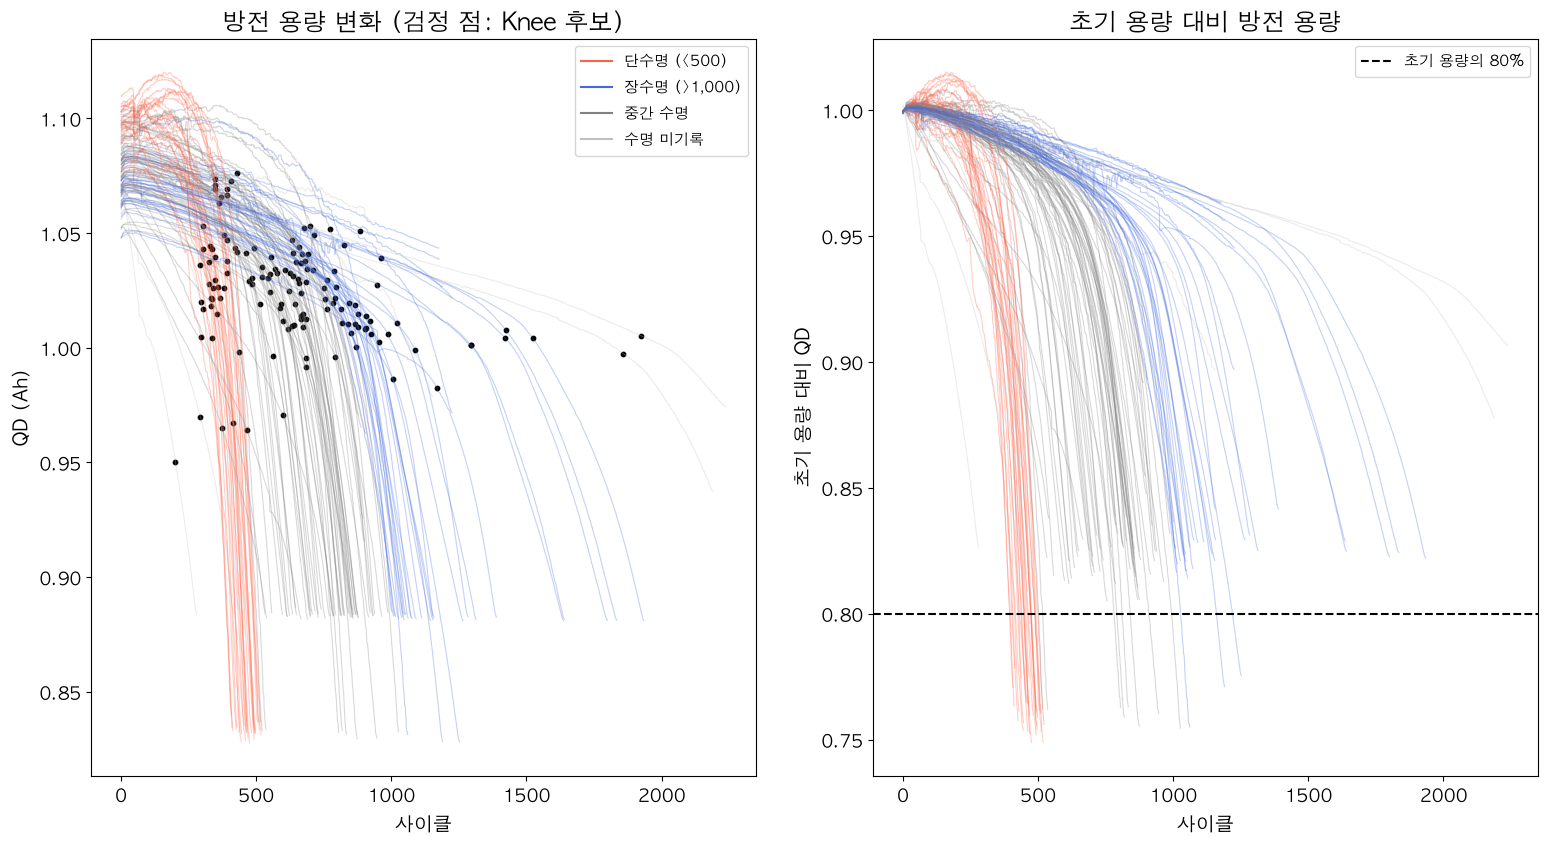

,cell_uid,cycle_life,early_QD_slope,late_QD_slope,acceleration_ratio,knee_cycle,knee_fit_improvement
0,Batch 1-cell-00,1190.0,-0.00002,-0.00006,2.94294,NaN,0.14910
1,Batch 1-cell-01,1179.0,-0.00002,-0.00005,2.07328,409.0,0.87685
2,Batch 1-cell-02,1177.0,-0.00002,-0.00005,2.41620,429.0,0.84003
3,Batch 1-cell-03,1226.0,-0.00002,-0.00027,12.38886,964.0,0.92818
4,Batch 1-cell-04,1227.0,-0.00002,-0.00009,4.62856,884.0,0.82579
...,...,...,...,...,...,...,...
134,Batch 3-cell-41,786.0,-0.00001,-0.00078,57.88671,599.0,0.95242
135,Batch 3-cell-42,1642.0,-0.00002,-0.00036,23.04112,1295.0,0.95119
136,Batch 3-cell-43,1046.0,-0.00001,-0.00071,65.93992,865.0,0.96546
137,Batch 3-cell-44,940.0,-0.00002,-0.00075,40.17038,784.0,0.93737


,early_QD_slope,late_QD_slope,acceleration_ratio
life_group,,,
long (>1000),-2.794885e-05,-0.000582,18.301410
middle,-3.254443e-05,-0.000806,22.951856
short (<500),1.287700e-04,-0.002045,17.971461
unknown,-9.453745e-07,-0.000192,3.140035


Knee는 전체 관측 수명으로 추정한 탐색 결과입니다. 초기 수명 예측 피쳐로 사용하면 미래 정보 누출입니다.


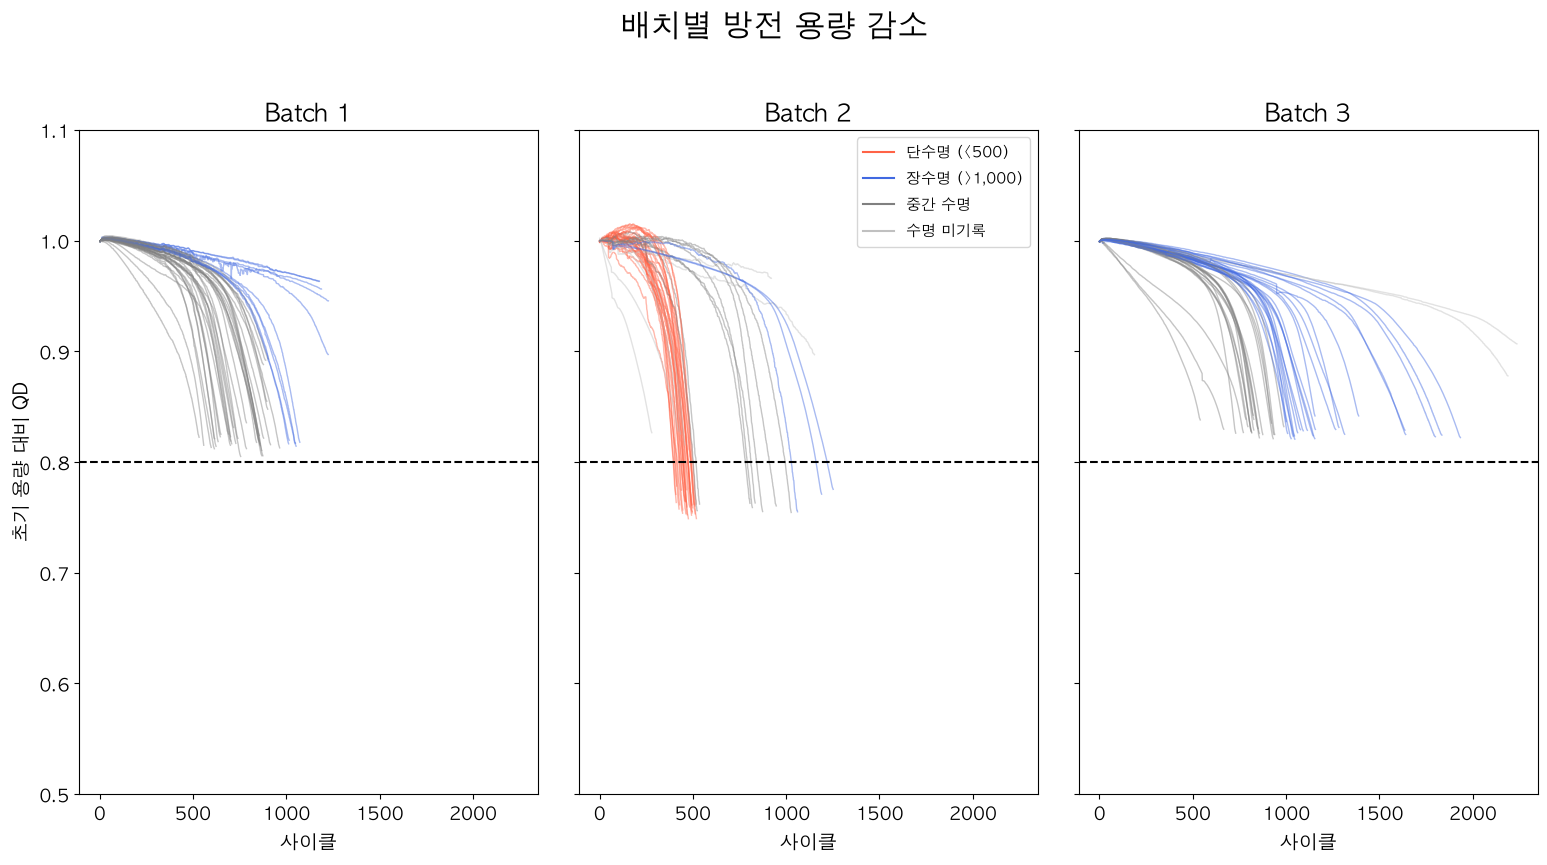

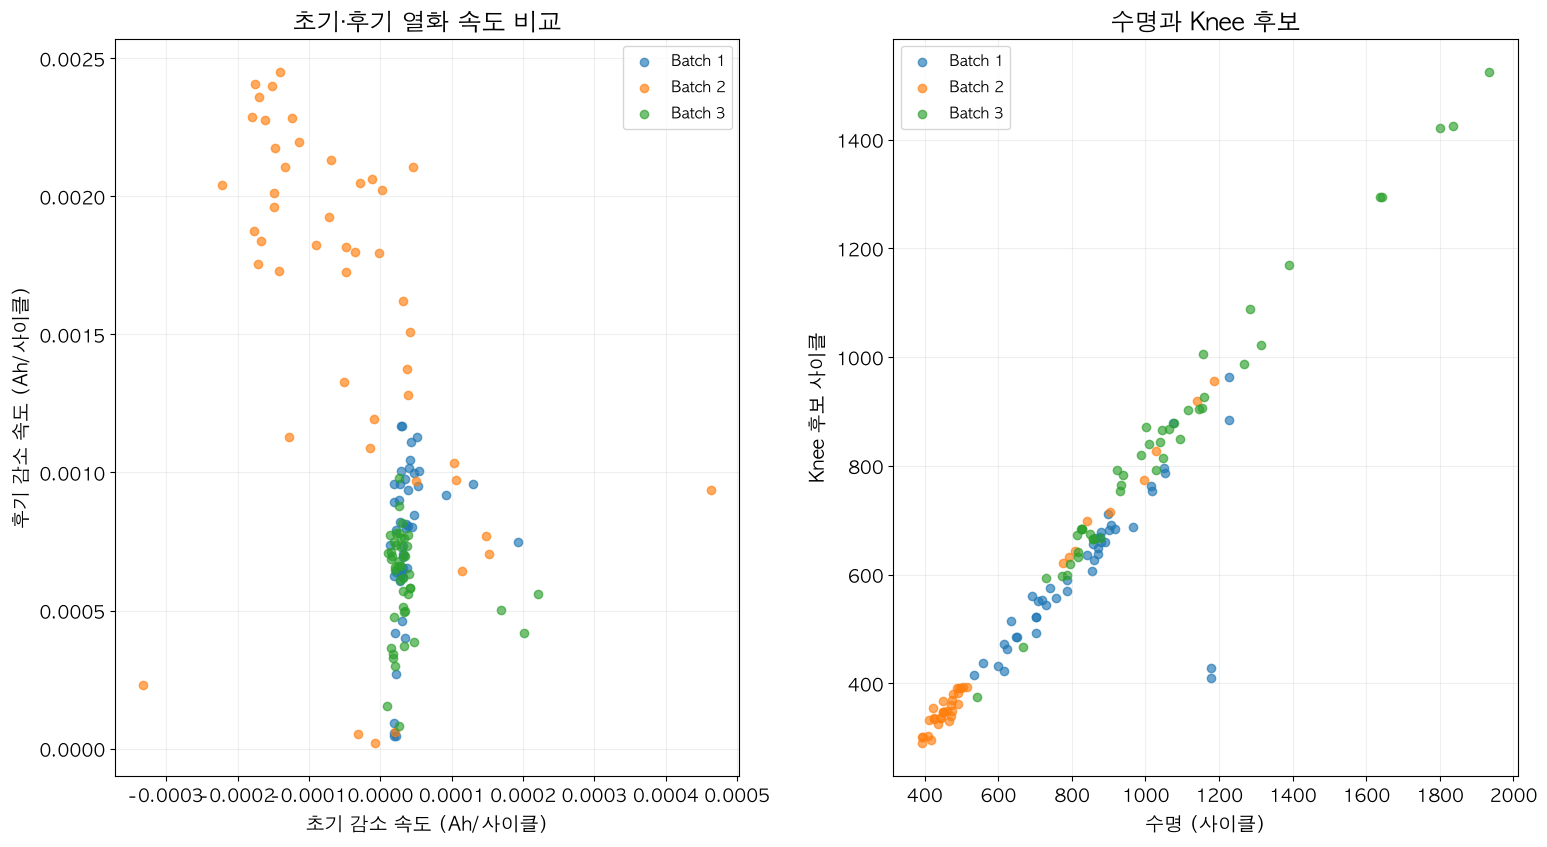

,early_QD_slope,late_QD_slope,acceleration_ratio,knee_cycle
batch,,,,
Batch 1,-0.000032,-0.000800,21.792815,607.0
Batch 2,0.000048,-0.001797,15.690145,352.0
Batch 3,-0.000028,-0.000653,21.522999,830.0


In [25]:
def slope_of(g):
    g=g[['cycle','QD']].dropna().sort_values('cycle')
    return np.polyfit(g.cycle,g.QD,1)[0] if len(g)>=10 and g.cycle.nunique()>1 else np.nan

def knee_fit(g):
    g=g[['cycle','QD']].dropna().sort_values('cycle').drop_duplicates('cycle')
    if len(g)<100: return (np.nan,np.nan,np.nan,np.nan)
    # 연속 힌지 회귀 y=a+b*x+c*max(0,x-k)
    x=g.cycle.to_numpy(); y=g.QD.rolling(11,center=True,min_periods=1).median().to_numpy()
    single=np.polyval(np.polyfit(x,y,1),x); sse0=((y-single)**2).sum()
    best=None
    for k in x[np.arange(max(30,len(x)//10),len(x)-max(30,len(x)//10),10)]:
        A=np.column_stack([np.ones(len(x)),x,np.maximum(0,x-k)])
        coef=np.linalg.lstsq(A,y,rcond=None)[0]; err=((y-A@coef)**2).sum()
        if best is None or err<best[0]: best=(err,k,coef)
    err,k,coef=best; before=coef[1]; after=coef[1]+coef[2]
    improvement=1-err/max(sse0,1e-12)
    accepted=improvement>.2 and after<0 and after<before and abs(after)>1.5*max(abs(before),1e-9)
    return (k if accepted else np.nan,before,after,improvement)

degradation_rows=[]; fig,axes=plt.subplots(1,2,figsize=(16,6))
for cid,g in eda[eda.valid_QD].groupby('cell_id'):
    g=g.sort_values('cycle'); meta=cell_meta.set_index('cell_id').loc[cid]
    color=colors[meta.life_group]
    smooth=g.QD.rolling(11,center=True,min_periods=1).median()
    axes[0].plot(g.cycle,smooth,color=color,alpha=.3,lw=.8)
    axes[1].plot(g.cycle,smooth/g.baseline_QD,color=color,alpha=.3,lw=.8)
    k,b,a,improvement=knee_fit(g)
    s1=slope_of(g[g.cycle.between(50,100)])
    s2=slope_of(g[g.cycle>=g.cycle.quantile(.8)])
    degradation_rows.append({'cell_id':cid,'early_QD_slope':s1,'late_QD_slope':s2,
       'acceleration_ratio':abs(s2)/abs(s1) if np.isfinite(s1) and abs(s1)>1e-8 else np.nan,
       'knee_cycle':k,'knee_slope_before':b,'knee_slope_after':a,'knee_fit_improvement':improvement})
    if np.isfinite(k): axes[0].scatter(k,smooth.iloc[(g.cycle-k).abs().to_numpy().argmin()],s=10,c='black')
axes[0].set(xlabel='Cycle',ylabel='QD (Ah)',title='Smoothed discharge capacity (black = knee candidate)')
axes[1].axhline(.8,color='black',ls='--',label='80% of initial QD')
axes[1].set(xlabel='Cycle',ylabel='QD / initial QD',title='Normalized capacity'); axes[1].legend()
from matplotlib.lines import Line2D
axes[0].legend(handles=[Line2D([0],[0],color=c,label=g) for g,c in colors.items()])
plt.tight_layout(); export_current()
degradation_df=cell_meta.merge(pd.DataFrame(degradation_rows),on='cell_id',how='left')
display(degradation_df[['cell_uid','cycle_life','early_QD_slope','late_QD_slope','acceleration_ratio','knee_cycle','knee_fit_improvement']].round(5))
display(degradation_df.groupby('life_group')[['early_QD_slope','late_QD_slope','acceleration_ratio']].median())
print('Knee는 전체 관측 수명으로 추정한 탐색 결과입니다. 초기 수명 예측 피쳐로 사용하면 미래 정보 누출입니다.')


fig,axes=plt.subplots(1,3,sharex=True,sharey=True)
for ax,(b,meta) in zip(axes,cell_meta.groupby('batch')):
    for _,m in meta.iterrows():
        g=eda[(eda.cell_id==m.cell_id)&eda.valid_QD].sort_values('cycle')
        y=(g.QD/g.baseline_QD).rolling(11,center=True,min_periods=1).median()
        ax.plot(g.cycle,y,color=colors[m.life_group],alpha=.45,lw=1)
    ax.axhline(.8,color='black',ls='--'); ax.set(title=b,xlabel='사이클',ylim=(.5,1.1))
axes[0].set_ylabel('초기 용량 대비 QD')
axes[1].legend(handles=[Line2D([0],[0],color=c,label=g) for g,c in colors.items()],fontsize=11)
fig.suptitle('배치별 방전 용량 감소',fontsize=22)
save_ppt(fig,'Q2_배치별_열화곡선')
fig,axes=plt.subplots(1,2)
for b,g in degradation_df.groupby('batch'):
    axes[0].scatter(-g.early_QD_slope,-g.late_QD_slope,label=b,alpha=.65)
    axes[1].scatter(g.cycle_life,g.knee_cycle,label=b,alpha=.65)
axes[0].set(xlabel='초기 감소 속도 (Ah/사이클)',ylabel='후기 감소 속도 (Ah/사이클)',title='초기·후기 열화 속도 비교')
axes[1].set(xlabel='수명 (사이클)',ylabel='Knee 후보 사이클',title='수명과 Knee 후보')
for ax in axes: ax.legend(); ax.grid(alpha=.2)
save_ppt(fig,'Q2_열화속도_Knee_배치비교')
display(degradation_df.groupby('batch')[['early_QD_slope','late_QD_slope','acceleration_ratio','knee_cycle']].median())


## 3. ΔQ(V)=Q100(V)−Q10(V) 및 충전 전류 피쳐 추출
HDF5 참조를 따라 필요한 사이클만 읽습니다. 초기 100-cycle 피쳐만 추출하고 원본 전체 시계열을 다시 로드하지 않습니다.

ΔQ 추출: 139 cells; charging current: 139 cells; skipped ΔQ: []


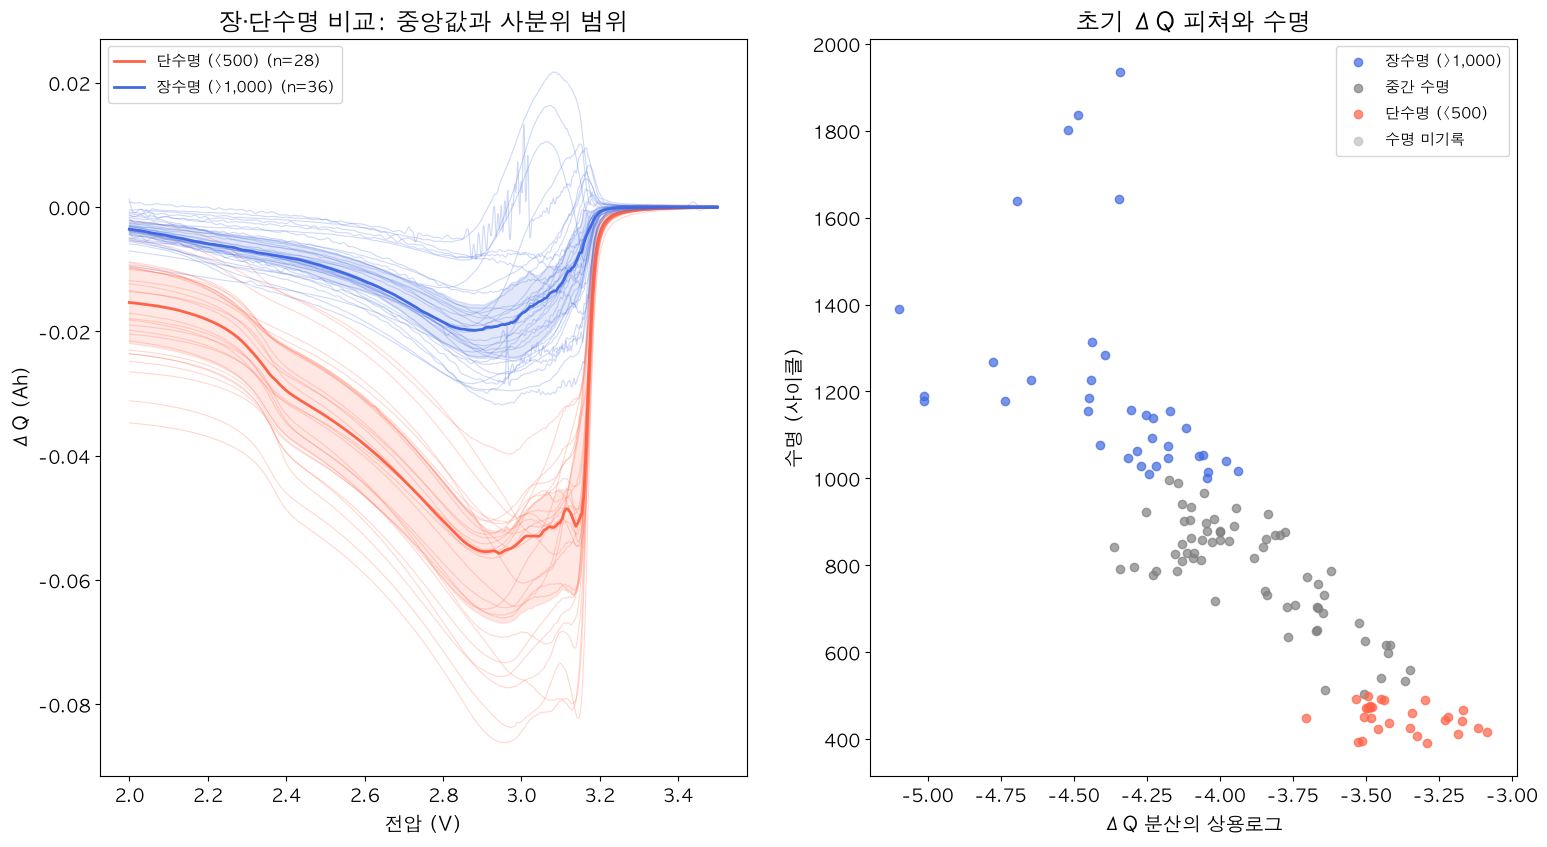

dq_mean            dq_std            dq_min            dq_max  \
                 mean      std     mean      std     mean      std     mean   
life_group                                                                    
long (>1000) -0.00830  0.00372  0.00684  0.00200 -0.02017  0.00677  0.00268   
middle       -0.01622  0.00628  0.01185  0.00376 -0.03591  0.01144  0.00017   
short (<500) -0.03002  0.00754  0.02060  0.00375 -0.06150  0.01160 -0.00002   
unknown      -0.02297  0.02600  0.01401  0.01330 -0.04374  0.03948  0.00352   

                      dq_range          dq_log_variance          dq_abs_mean  \
                  std     mean      std            mean      std        mean   
life_group                                                                     
long (>1000)  0.00530  0.02285  0.00539        -4.37254  0.28956     0.00865   
middle        0.00099  0.03609  0.01134        -3.89261  0.26278     0.01624   
short (<500)  0.00013  0.06148  0.01161        -3.38540  0.15361     0.03003   
unknown       0.00622  0.04726  0.03646        -4.00622  0.73281     0.02334   

                       dq_skew          dq_kurtosis           
                  std     mean      std        mean      std  
life_group                                                    
long (>1000)  0.00322 -0.07147  0.57467    -0.69853  1.15583  
middle        0.00627 -0.17155  0.21464    -1.19788  0.12664  
short (<500)  0.00755  0.01203  0.26325    -1.22553  0.14054  
unknown       0.02570  0.23584  1.59534     1.83745  6.28913

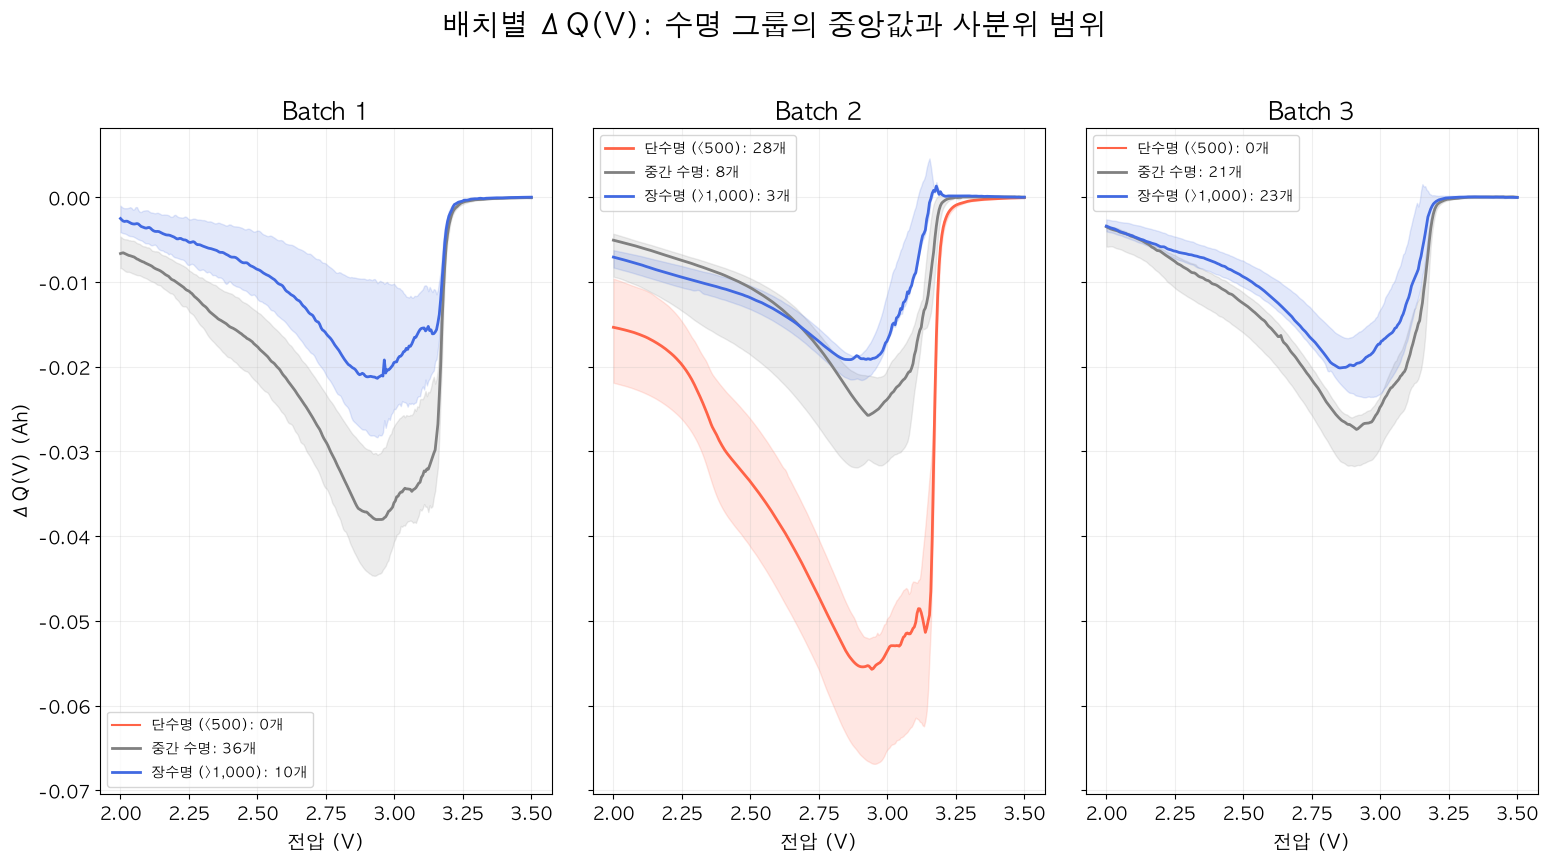

dq_mean              dq_min              dq_std            \
             mean       std      mean       std      mean       std   
batch                                                                 
Batch 1 -0.016024  0.006854 -0.035969  0.012945  0.011835  0.004333   
Batch 2 -0.025405  0.014506 -0.051880  0.023568  0.017178  0.008015   
Batch 3 -0.010693  0.005797 -0.024499  0.009923  0.008300  0.002982   

        dq_log_variance            
                   mean       std  
batch                              
Batch 1       -3.922996  0.378273  
Batch 2       -3.640079  0.472550  
Batch 3       -4.211797  0.298564

In [26]:
def read_numeric(f,node):
    if node is None or node.attrs.get('MATLAB_empty',0): return np.array([])
    try: return np.asarray(node[()],dtype=float).ravel()
    except (ValueError,TypeError): return np.array([])

def ref_node(f,refs,index):
    refs=np.asarray(refs[()]).ravel()
    return f[refs[index]] if index<len(refs) and refs[index] else None

def cycle_array(f,cyc,key,index):
    return read_numeric(f,ref_node(f,cyc[key],index)) if key in cyc else np.array([])

dq_rows=[]; current_rows=[]; dq_curves={}; current_examples={}; skipped=[]
for batch_name,filename in BATCH_FILES.items():
    with h5py.File(os.path.join(DATA_DIR,filename),'r') as f:
        raw=f['batch']
        for _,meta in cell_meta[cell_meta.batch.eq(batch_name)].iterrows():
            cid=int(meta.cell_id); local=int(meta.local_cell_id)
            cyc=ref_node(f,raw['cycles'],local)
            v=read_numeric(f,ref_node(f,raw['Vdlin'],local))
            q10=cycle_array(f,cyc,'Qdlin',9); q100=cycle_array(f,cyc,'Qdlin',99)
            if len(v)==len(q10)==len(q100) and len(v)>10:
                ok=np.isfinite(v)&np.isfinite(q10)&np.isfinite(q100)
                vv=v[ok]; dq=(q100-q10)[ok]; order=np.argsort(vv); vv=vv[order]; dq=dq[order]
                if len(dq)>10:
                    dq_curves[cid]=(vv,dq)
                    dq_rows.append({'cell_id':cid,'dq_mean':dq.mean(),'dq_std':dq.std(ddof=1),
                        'dq_min':dq.min(),'dq_max':dq.max(),'dq_range':np.ptp(dq),
                        'dq_log_variance':np.log10(max(np.var(dq,ddof=1),1e-15)),
                        'dq_abs_mean':abs(dq).mean(),'dq_skew':stats.skew(dq),
                        'dq_kurtosis':stats.kurtosis(dq)})
            else: skipped.append(meta.cell_uid)
            # 양의 전류를 충전으로 정의합니다. t: 분, I: A.
            measurements=[]
            for index in range(1,100):
                I=cycle_array(f,cyc,'I',index); t=cycle_array(f,cyc,'t',index)
                if len(I)!=len(t) or len(I)<2: continue
                dt=np.diff(t); midI=(I[:-1]+I[1:])/2
                mask=np.isfinite(dt)&np.isfinite(midI)&(dt>0)&(midI>.05)
                if not mask.any(): continue
                duration=dt[mask].sum(); avg=np.average(midI[mask],weights=dt[mask])
                q0=baseline.get(cid,np.nan)
                measurements.append([avg,np.max(midI[mask]),duration,
                    dt[mask & (midI>4*q0)].sum()/duration if np.isfinite(q0) else np.nan])
                if index==9: current_examples[cid]=(t,I)
            if measurements:
                a=np.asarray(measurements)
                current_rows.append({'cell_id':cid,'charge_I_mean':np.mean(a[:,0]),
                    'charge_I_peak':np.mean(a[:,1]),'charge_duration_min':np.mean(a[:,2]),
                    'charge_fraction_above_4C':np.nanmean(a[:,3]),'charge_cycles_observed':len(a),
                    'charge_C_mean':np.mean(a[:,0])/baseline.get(cid,np.nan)})

dq_features=pd.DataFrame(dq_rows).reindex(columns=['cell_id','dq_mean','dq_std','dq_min','dq_max','dq_range','dq_log_variance','dq_abs_mean','dq_skew','dq_kurtosis'])
current_features=pd.DataFrame(current_rows)
print(f'ΔQ 추출: {len(dq_features)} cells; charging current: {len(current_features)} cells; skipped ΔQ: {skipped}')
fig,axes=plt.subplots(1,2,figsize=(15,5)); grid=np.linspace(2,3.5,300)
for group in ['short (<500)','long (>1000)']:
    curves=[]
    for cid in cell_meta.loc[cell_meta.life_group.eq(group),'cell_id']:
        if cid not in dq_curves: continue
        v,dq=dq_curves[cid]; axes[0].plot(v,dq,color=colors[group],alpha=.25,lw=.8)
        curves.append(np.interp(grid,v,dq,left=np.nan,right=np.nan))
    if curves:
        a=np.array(curves); med=np.nanmedian(a,axis=0); low,high=np.nanpercentile(a,[25,75],axis=0)
        axes[0].plot(grid,med,color=colors[group],lw=2,label=f'{group} (n={len(curves)})')
        axes[0].fill_between(grid,low,high,color=colors[group],alpha=.15)
axes[0].set(xlabel='Voltage (V)',ylabel='ΔQ (Ah)',title='Short vs long: median and IQR'); axes[0].legend()
dq_comparison=cell_meta.merge(dq_features,on='cell_id',how='inner')
for group,g in dq_comparison.groupby('life_group'):
    axes[1].scatter(g.dq_log_variance,g.cycle_life,color=colors[group],label=group,alpha=.7)
axes[1].set(xlabel='log10 variance(ΔQ)',ylabel='Cycle life',title='Early ΔQ feature vs life'); axes[1].legend()
plt.tight_layout(); export_current()
display(dq_comparison.groupby('life_group')[dq_features.columns.drop('cell_id')].agg(['mean','std']).round(5))


fig,axes=plt.subplots(1,3,sharex=True,sharey=True)
for ax,(b,meta) in zip(axes,cell_meta.groupby('batch')):
    for group in ['short (<500)','middle','long (>1000)']:
        ids=[cid for cid in meta.loc[meta.life_group.eq(group),'cell_id'] if cid in dq_curves]
        if not ids:
            ax.plot([],[],color=colors[group],label=f'{group}: 0개')
            continue
        curve_set=[dq_curves[cid] for cid in ids]
        low=max(v.min() for v,d in curve_set); high=min(v.max() for v,d in curve_set)
        grid_b=np.linspace(low,high,300)
        arr=np.array([np.interp(grid_b,v,d) for v,d in curve_set])
        q25,q50,q75=np.percentile(arr,[25,50,75],axis=0)
        ax.plot(grid_b,q50,color=colors[group],label=f'{group}: {len(ids)}개',lw=2)
        ax.fill_between(grid_b,q25,q75,color=colors[group],alpha=.15)
    ax.set(title=b,xlabel='전압 (V)');ax.legend(fontsize=10);ax.grid(alpha=.2)
axes[0].set_ylabel('ΔQ(V) (Ah)')
fig.suptitle('배치별 ΔQ(V): 수명 그룹의 중앙값과 사분위 범위',fontsize=21)
save_ppt(fig,'Q3_배치별_DeltaQ_수명그룹')
display(dq_comparison.groupby('batch')[['dq_mean','dq_min','dq_std','dq_log_variance']].agg(['mean','std']))


## 4. 충전 프로토콜·실제 충전 전류와 수명/열화 속도

mean     std  count
batch   charging_policy                                    
Batch 3 4.8C(80%)-4.8C-newstructure  1564.17  285.72      6
Batch 1 4C(80%)-4C                   1226.50    0.71      2
        3.6C(80%)-3.6C               1182.00    7.00      3
Batch 3 5C(67%)-4C-newstructure      1105.71  402.91      7
        5.3C(54%)-4C-newstructure    1074.38  129.67      8
Batch 1 4.4C(80%)-4.4C               1074.00     NaN      1
        8C(15%)-3.6C                 1008.50   60.10      2
Batch 3 5.6C(19%)-4.6C-newstructure  1001.38  174.56      8
Batch 2 5.6C(26%)-4.5C-newstructure   991.33  197.56      3
Batch 1 5.4C(40%)-3.6C                966.50  123.74      2
Batch 2 5.2C(58%)-4C-newstructure     961.67  157.62      3
Batch 1 6C(30%)-3.6C                  952.50   86.97      2
        6C(40%)-3C                    935.50  115.26      2
Batch 3 5.6C(36%)-4.3C-newstructure   930.88  135.02      8
Batch 1 5.4C(50%)-3.6C                899.50    3.54      2
        6C(50%)-3C                    888.50   40.31      2
Batch 2 4.8C(80%)-4.8C-newstructure   871.67  137.19      3
Batch 3 5.9C(15%)-4.6C-newstructure   867.00   12.73      2
        5.9C(60%)-3.1C-newstructure   866.50  191.63      2
Batch 1 5.4C(60%)-3.6C                859.50    3.54      2
        6C(40%)-3.6C                  856.00   19.80      2
        5.4C(50%)-3C                  847.00   83.44      2
        5.4C(60%)-3C                  799.50  113.84      2
        6C(50%)-3.6C                  792.50  118.09      2
        4.8C(80%)-4.8C                753.00  165.46      2
        6C(60%)-3C                    744.00   18.38      2
        5.4C(70%)-3C                  739.50   68.59      2
        7C(30%)-3.6C                  722.50   27.58      2
        8C(25%)-3.6C                  676.50   36.06      2
        7C(40%)-3C                    676.00   39.60      2
Batch 3 3.7C(31%)-5.9C-newstructure   660.00  115.66      3
Batch 1 7C(40%)-3.6C                  621.00    5.66      2
        8C(35%)-3.6C                  607.50   12.02      2
        5.4C(80%)-5.4C                546.50   17.68      2
Batch 2 4.8C(80%)-4.8C                483.60   30.32      5
        4.65C(44%)-5C                 482.50   23.33      2
        5.2C(58%)-4C                  477.75   18.46      4
        5.2C(50%)-4.25C               454.00   20.92      5
        4.65C(69%)-6C                 452.00   11.31      2
        5.6C(26%)-4.5C                448.50   29.13      6
        3.6C(30%)-6C                  421.00    7.07      2
        6C(60%)-3C                    400.00   11.31      2
        3.6C(9%)-5C                   394.50    2.12      2

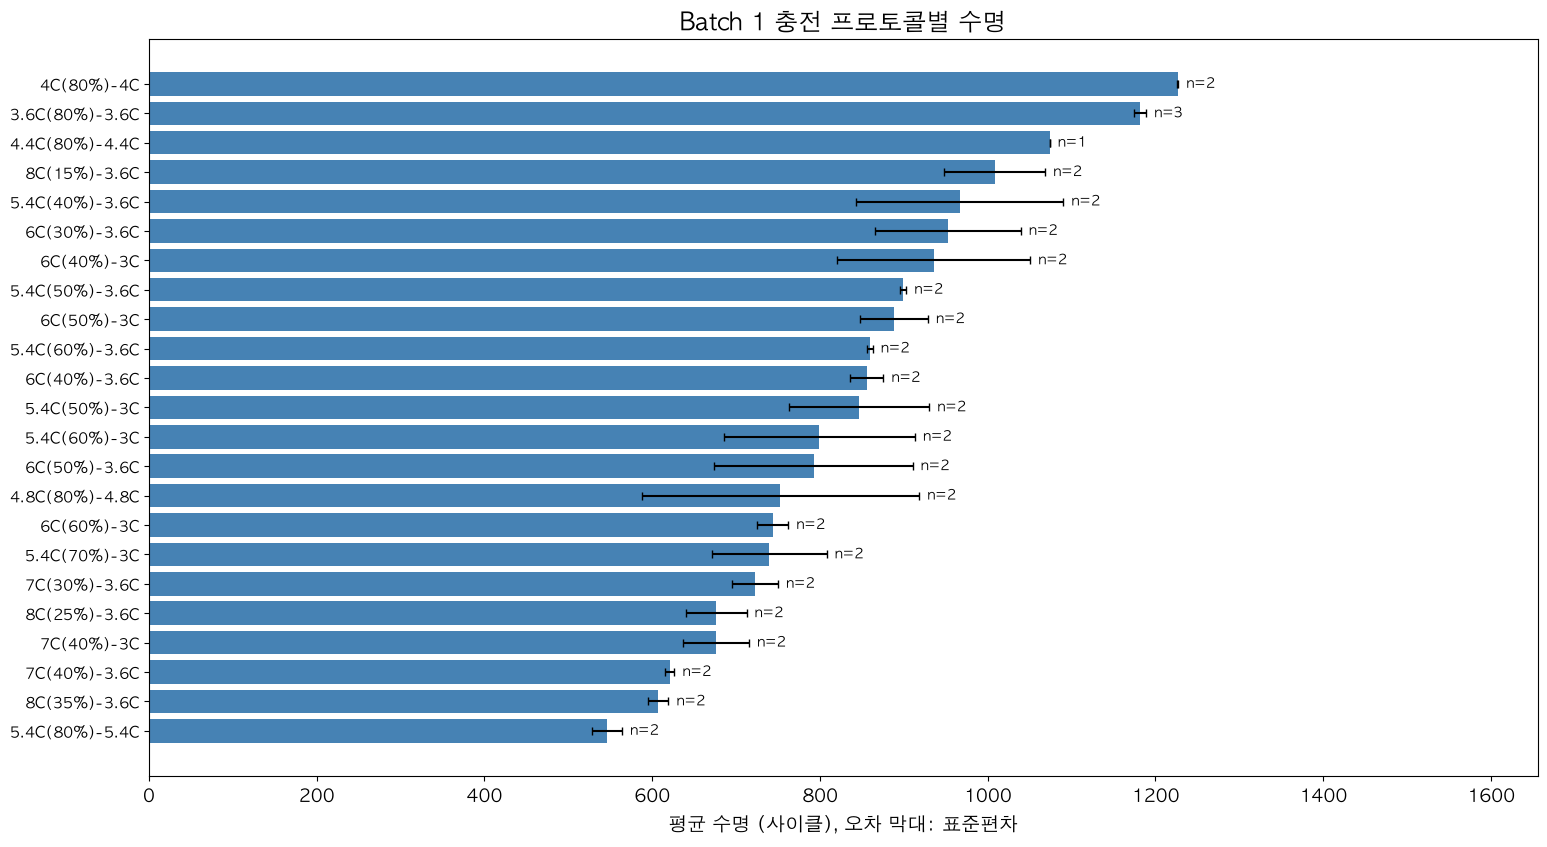

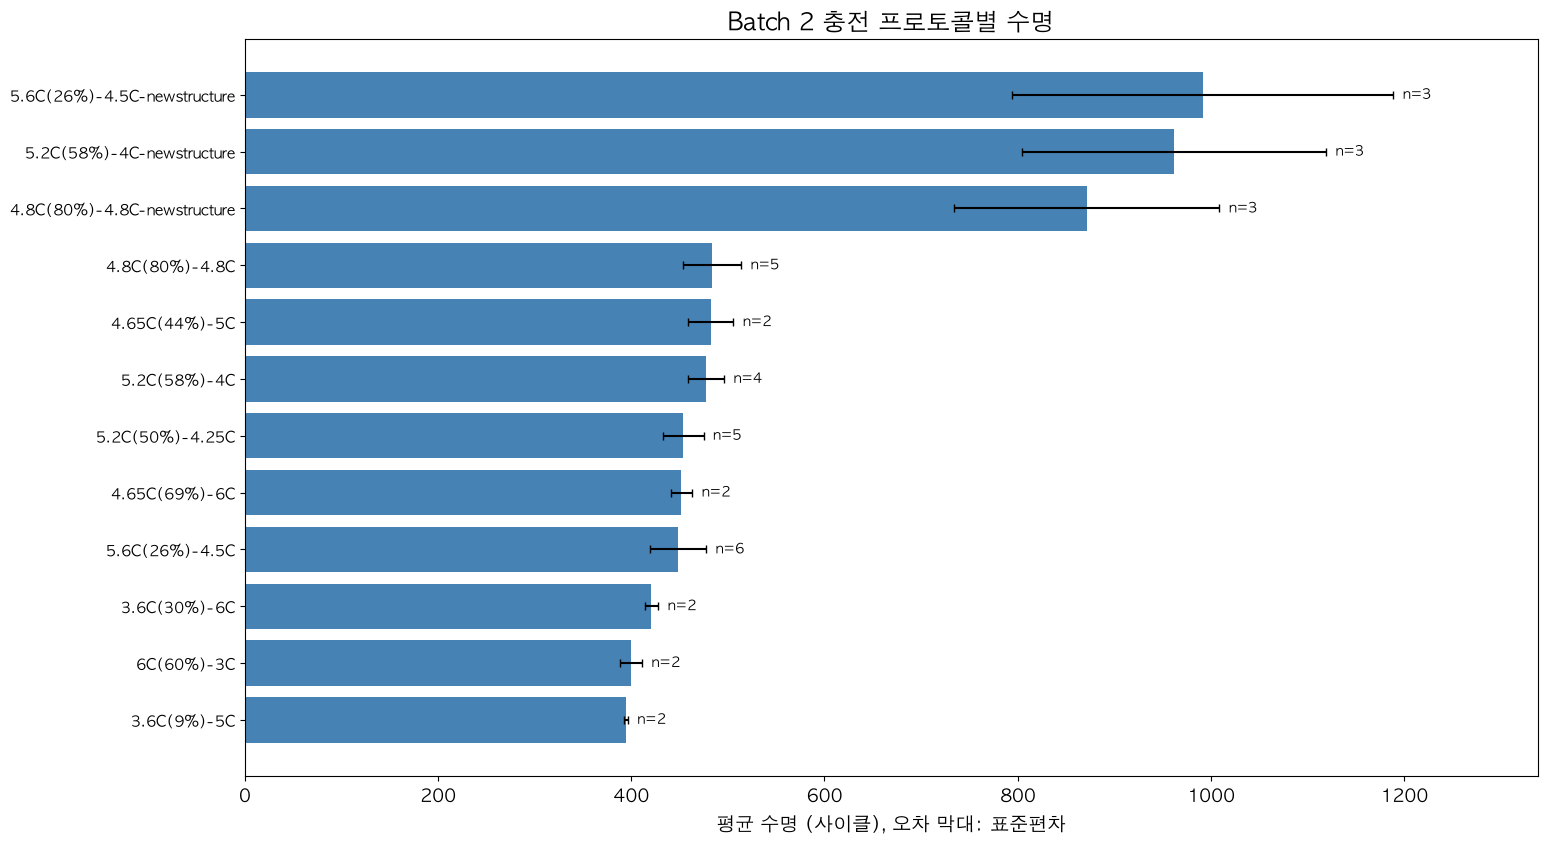

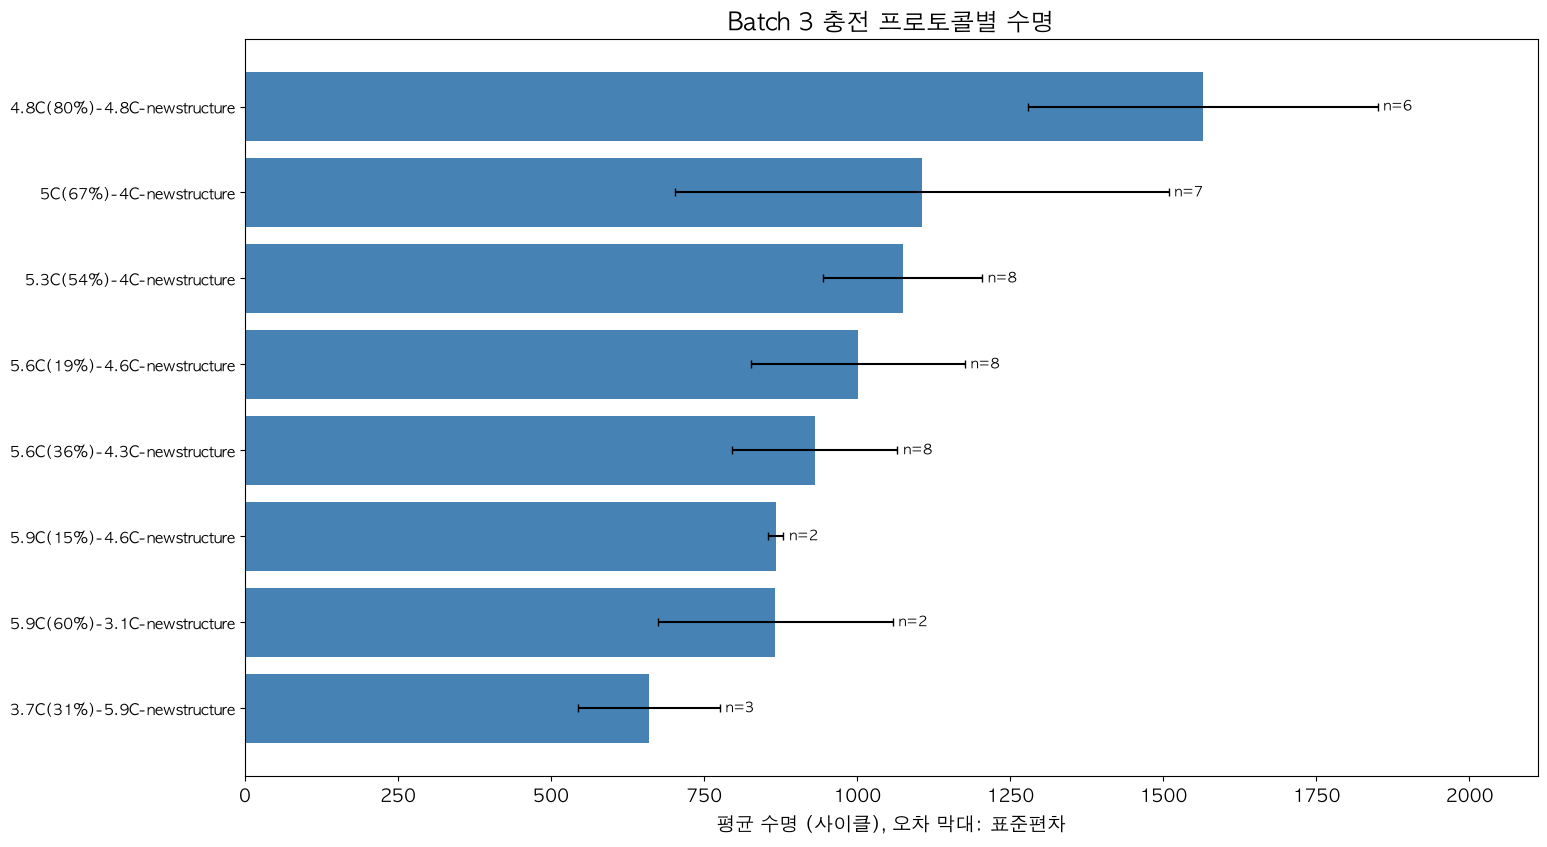

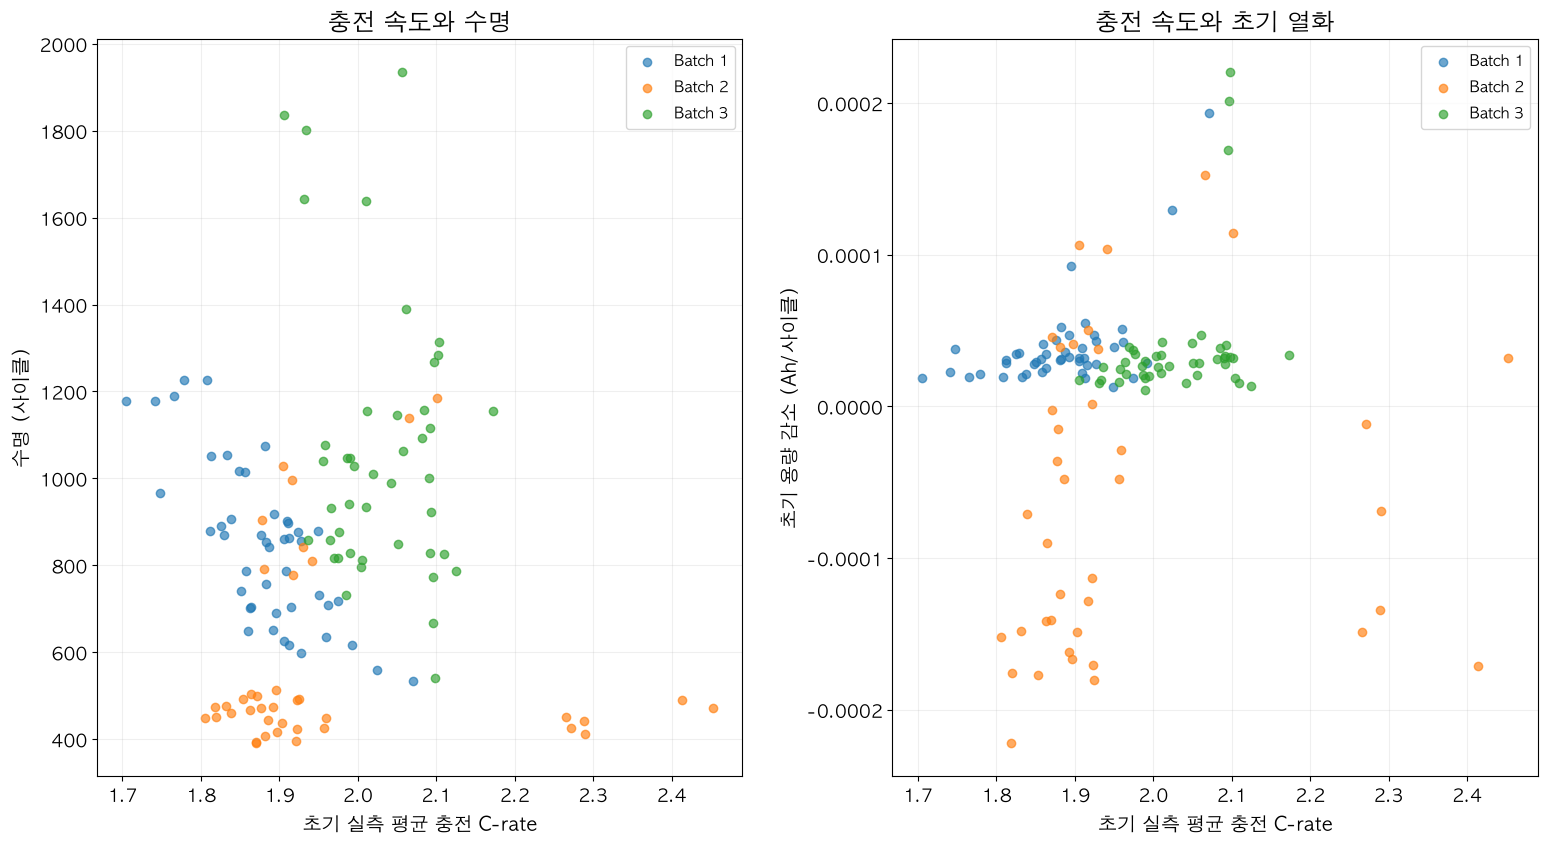

,cycle_life,early_QD_slope
policy_C1,-0.027,-0.276
policy_C2,-0.146,0.055
equivalent_C,-0.242,0.028
charge_C_mean,0.117,-0.186
charge_I_peak,-0.251,-0.328
charge_fraction_above_4C,0.030,0.086
charge_duration_min,-0.292,0.331
cycle_life,1.000,-0.273
early_QD_slope,-0.273,1.000


배치별 전류–수명 Spearman:
Batch 1 -0.701
Batch 2 0.039
Batch 3 -0.066


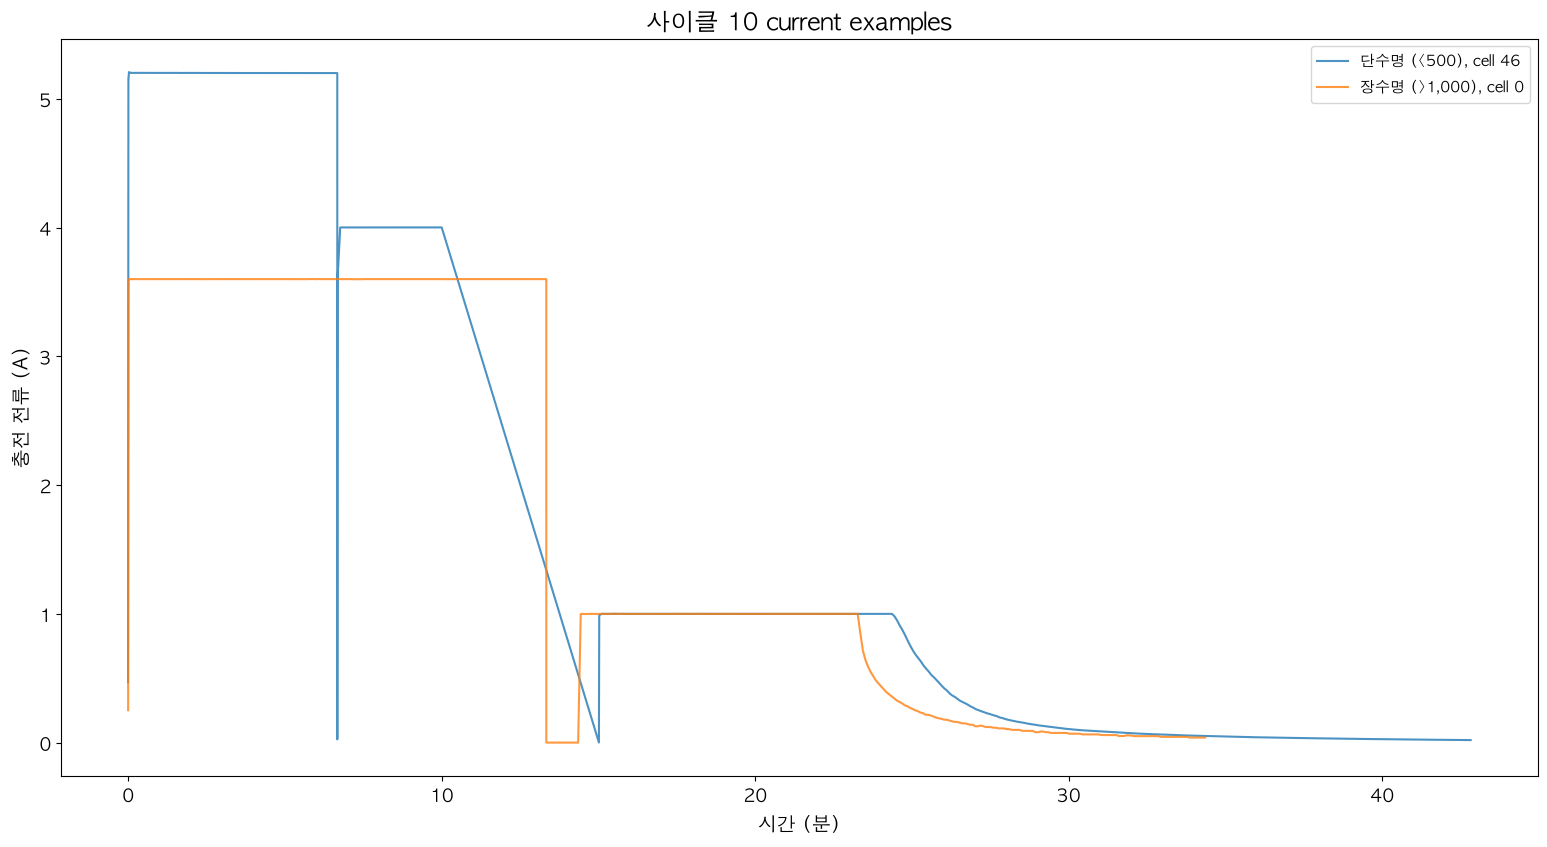

정책별 표본 수와 batch 차이를 함께 해석하세요. 단순 상관만으로 인과를 판단할 수 없습니다.


In [27]:
def policy_values(text):
    match=re.search(r'(\d+(?:\.\d+)?)C\((\d+(?:\.\d+)?)%\)-(\d+(?:\.\d+)?)C',str(text))
    if not match: return [np.nan]*4
    c1,p,c2=map(float,match.groups()); f=p/100
    # SOC 구간의 일정 전류 가정에서 충전시간 등가 C-rate (산술 평균이 아님)
    equivalent=1/(f/c1+(1-f)/c2)
    return [c1,c2,f,equivalent]

policy_features=cell_meta[['cell_id','charging_policy']].copy()
policy_features[['policy_C1','policy_C2','switch_SOC','equivalent_C']]=pd.DataFrame(
    policy_features.charging_policy.map(policy_values).tolist(),index=policy_features.index)
charging_df=degradation_df.merge(policy_features.drop(columns='charging_policy'),on='cell_id',how='left').merge(current_features,on='cell_id',how='left')
valid=charging_df.dropna(subset=['cycle_life'])
policy_life=valid.groupby(['batch','charging_policy']).cycle_life.agg(['mean','std','count']).sort_values('mean',ascending=False)
display(policy_life.round(2))
for b,g in valid.groupby('batch'):
    table=g.groupby('charging_policy').cycle_life.agg(['mean','std','count']).sort_values('mean')
    fig,ax=plt.subplots()
    pos=np.arange(len(table))
    ax.barh(pos,table['mean'],xerr=table['std'].fillna(0),color='steelblue',capsize=3)
    ax.set_yticks(pos);ax.set_yticklabels(table.index,fontsize=11)
    for i,row in enumerate(table.itertuples()):
        ax.text(row.mean+max(0,row.std if np.isfinite(row.std) else 0)+10,i,f'n={row.count}',va='center',fontsize=10)
    ax.set(xlabel='평균 수명 (사이클), 오차 막대: 표준편차',title=f'{b} 충전 프로토콜별 수명')
    ax.set_xlim(0,table['mean'].max()*1.35)
    save_ppt(fig,f'Q4_{b.replace(" ","_")}_프로토콜별수명')
fig,axes=plt.subplots(1,2)
for b,g in valid.groupby('batch'):
    axes[0].scatter(g.charge_C_mean,g.cycle_life,label=b,alpha=.65)
    axes[1].scatter(g.charge_C_mean,-g.early_QD_slope,label=b,alpha=.65)
axes[0].set(xlabel='초기 실측 평균 충전 C-rate',ylabel='수명 (사이클)',title='충전 속도와 수명')
axes[1].set(xlabel='초기 실측 평균 충전 C-rate',ylabel='초기 용량 감소 (Ah/사이클)',title='충전 속도와 초기 열화')
for ax in axes: ax.legend();ax.grid(alpha=.2)
save_ppt(fig,'Q4_실측충전속도_열화비교')
signals=['policy_C1','policy_C2','equivalent_C','charge_C_mean','charge_I_peak','charge_fraction_above_4C','charge_duration_min']
display(valid[signals+['cycle_life','early_QD_slope']].corr(method='spearman')[['cycle_life','early_QD_slope']].round(3))
print('배치별 전류–수명 Spearman:')
for b,g in valid.groupby('batch'): print(b,round(g.charge_C_mean.corr(g.cycle_life,method='spearman'),3))
fig,ax=plt.subplots(figsize=(10,4))
for group in ['short (<500)','long (>1000)']:
    candidates=cell_meta.loc[cell_meta.life_group.eq(group),'cell_id']
    cid=next((c for c in candidates if c in current_examples),None)
    if cid is not None:
        t,I=current_examples[cid]; mask=np.isfinite(t)&np.isfinite(I)&(I>0)
        ax.plot(t[mask]-np.nanmin(t),I[mask],label=f'{group}, cell {cid}',alpha=.8)
ax.set(xlabel='Time (min)',ylabel='Charging current (A)',title='Cycle 10 current examples'); ax.legend()
plt.tight_layout(); export_current()
print('정책별 표본 수와 batch 차이를 함께 해석하세요. 단순 상관만으로 인과를 판단할 수 없습니다.')


## 5. 초기 피쳐–Cycle Life 상관관계와 다중공선성
Knee와 후기 열화 속도는 미래 정보이므로 초기 피쳐 상관 분석에서 제외합니다.

,n,pearson,spearman
feature,,,
dq_log_variance,129,-0.851,-0.892
dq_min,129,0.827,0.883
dq_std,129,-0.824,-0.892
dq_range,129,-0.800,-0.868
dq_mean,129,0.797,0.869
dq_abs_mean,129,-0.792,-0.870
early_QD_mean,129,-0.497,-0.504
early_QD_slope,129,-0.398,-0.273
dq_max,129,0.383,0.287


가장 강한 Pearson 관계: dq_log_variance -0.851


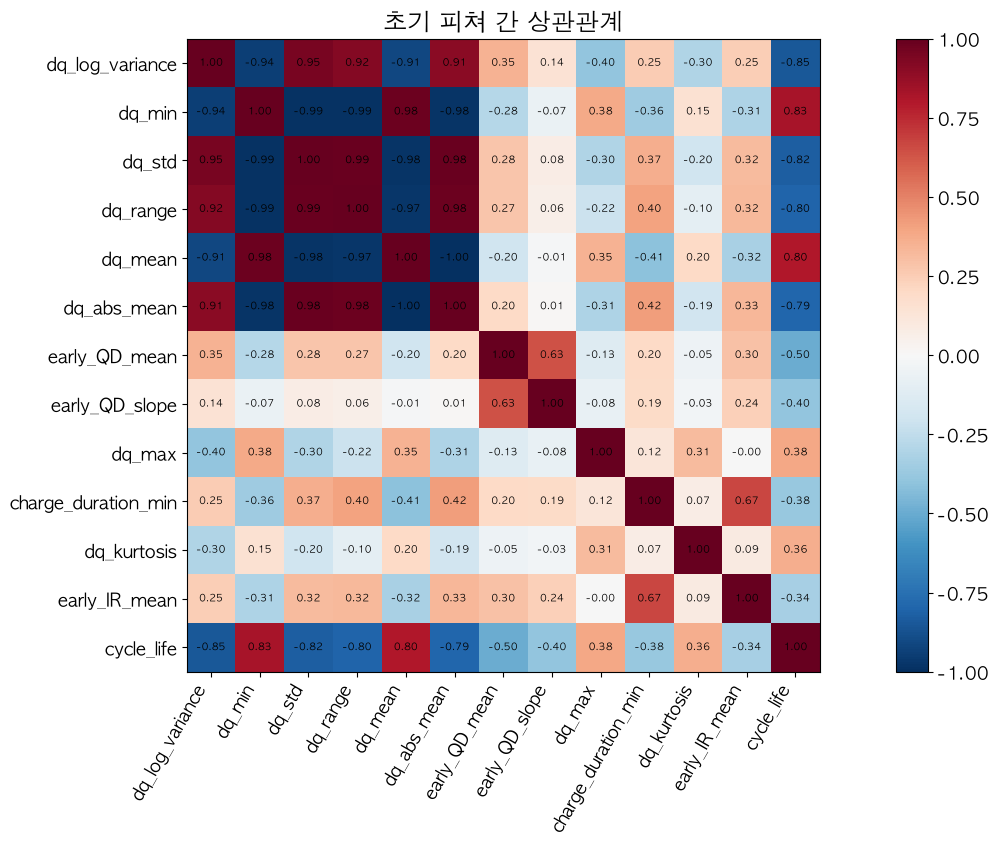

,feature_1,feature_2,pearson
14,dq_mean,dq_abs_mean,-0.999008
15,charge_I_mean,charge_C_mean,0.992563
5,dq_min,dq_std,-0.991267
9,dq_std,dq_range,0.989859
6,dq_min,dq_range,-0.985769
11,dq_std,dq_abs_mean,0.984848
7,dq_min,dq_mean,0.983269
10,dq_std,dq_mean,-0.983158
8,dq_min,dq_abs_mean,-0.981156
13,dq_range,dq_abs_mean,0.978132


VIF complete-case cells: 123


,feature,VIF
1,dq_min,inf
3,dq_range,inf
8,dq_max,inf
5,dq_abs_mean,6427.50
4,dq_mean,6413.86
24,charge_C_mean,3025.07
19,charge_I_mean,2741.23
2,dq_std,554.41
6,early_QD_mean,140.65
0,dq_log_variance,52.17


VIF>5는 검토, >10은 강한 다중공선성 후보. ΔQ 통계량과 온도 변수는 대표 피쳐 선택 또는 정규화를 고려하세요.
피쳐 선택과 결측 대체는 모델링 시 학습 데이터 안에서 수행해야 합니다.


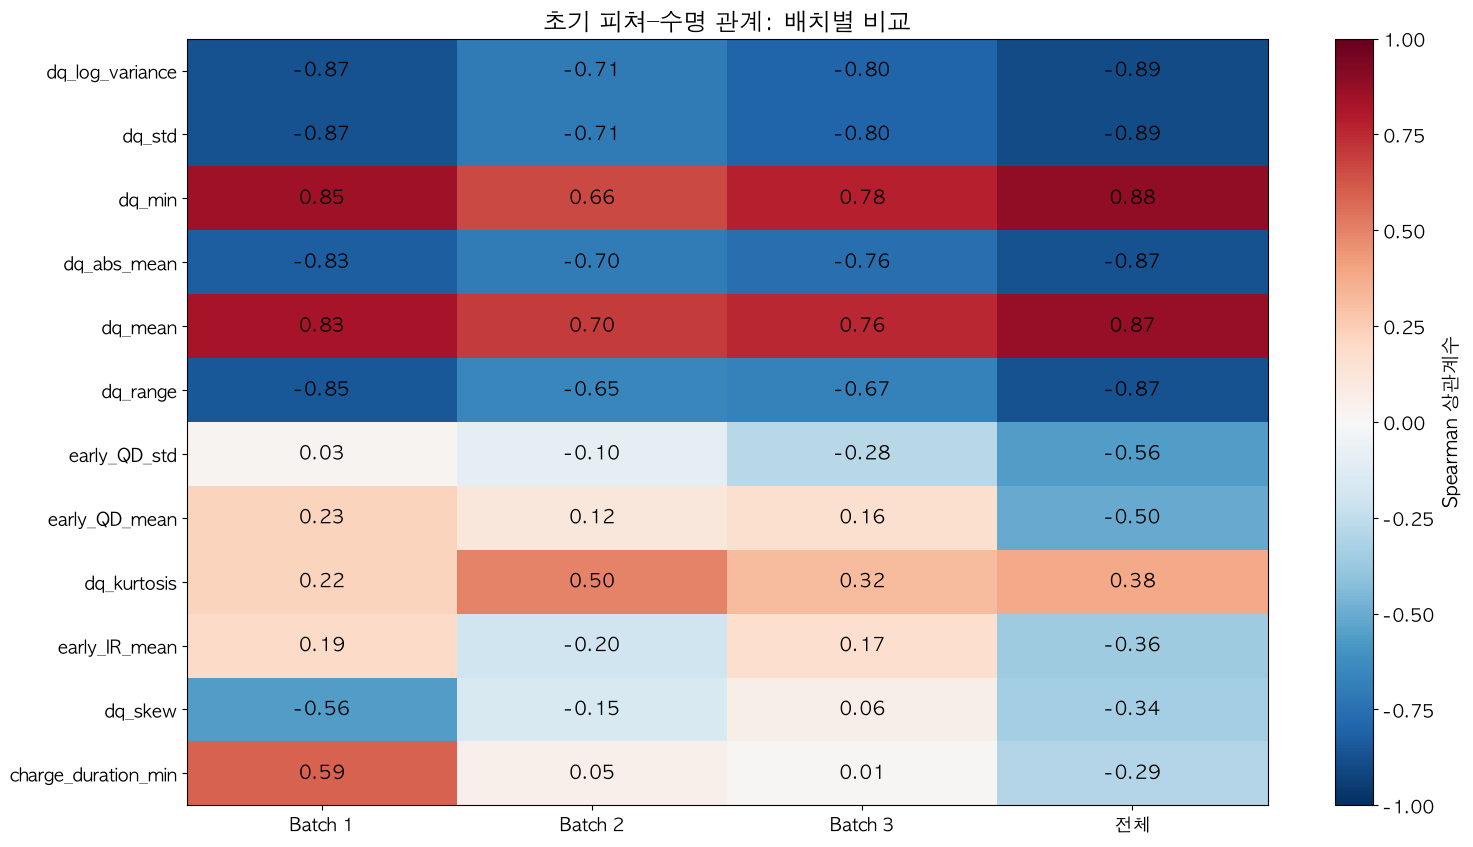

,Batch 1,Batch 2,Batch 3
dq_log_variance,3.48,1.74,2.01
early_QD_mean,1.34,1.99,3.10
early_IR_mean,1.45,2.60,2.29
early_Tavg_mean,1.65,1.40,1.67
charge_C_mean,2.88,1.42,2.99
early_QD_slope,2.09,2.68,4.43


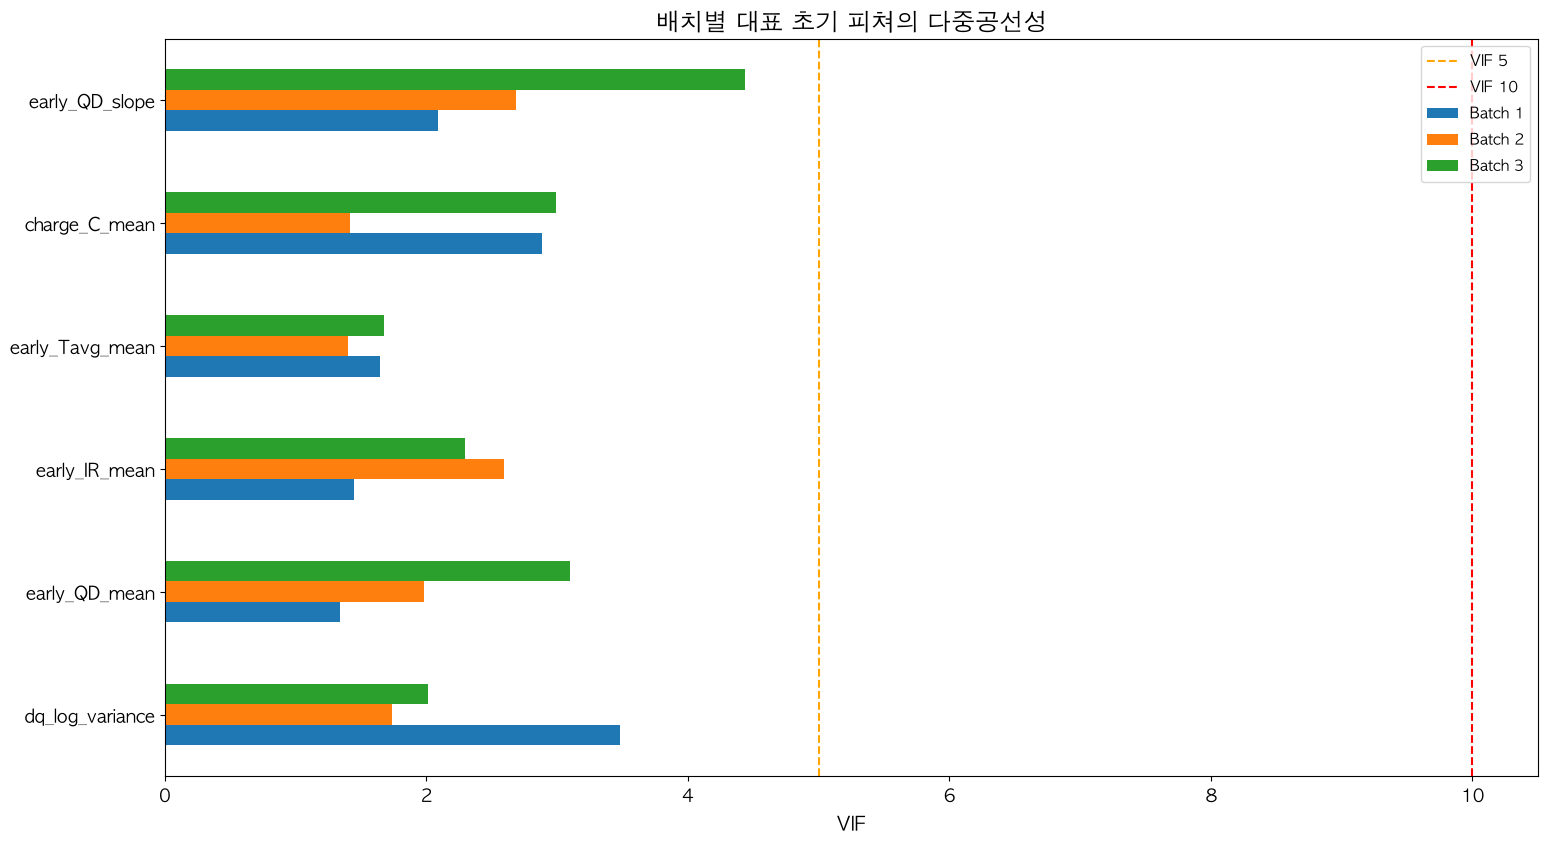

In [28]:
feature_df=(cell_meta.merge(early_features,on='cell_id',how='left')
    .merge(degradation_df[['cell_id','early_QD_slope']],on='cell_id',how='left')
    .merge(dq_features,on='cell_id',how='left')
    .merge(current_features,on='cell_id',how='left')
    .merge(policy_features.drop(columns='charging_policy'),on='cell_id',how='left'))
exclude={'cell_id','local_cell_id','cycle_life','early_cycles','charge_cycles_observed'}
cols=[c for c in feature_df.select_dtypes(include='number').columns if c not in exclude]
rows=[]
for c in cols:
    pairs=feature_df[[c,'cycle_life']].replace([np.inf,-np.inf],np.nan).dropna()
    if len(pairs)<5 or pairs[c].nunique()<2: continue
    r=pairs[c].corr(pairs.cycle_life); rho=pairs[c].corr(pairs.cycle_life,method='spearman')
    rows.append({'feature':c,'n':len(pairs),'pearson':r,'spearman':rho})
correlation_rank=pd.DataFrame(rows).set_index('feature')
correlation_rank=correlation_rank.loc[correlation_rank.pearson.abs().sort_values(ascending=False).index]
display(correlation_rank.round(3))
print('가장 강한 Pearson 관계:',correlation_rank.index[0],round(correlation_rank.pearson.iloc[0],3))

top=correlation_rank.head(12).index.tolist()
matrix=feature_df[top+['cycle_life']].corr()
fig,ax=plt.subplots(figsize=(11,9)); im=ax.imshow(matrix,cmap='RdBu_r',vmin=-1,vmax=1)
plt.colorbar(im,ax=ax); ax.set_xticks(range(len(matrix))); ax.set_yticks(range(len(matrix)))
ax.set_xticklabels(matrix.columns,rotation=60,ha='right'); ax.set_yticklabels(matrix.index)
for i in range(len(matrix)):
    for j in range(len(matrix)): ax.text(j,i,f'{matrix.iloc[i,j]:.2f}',ha='center',va='center',fontsize=7)
ax.set_title('Early feature correlations'); plt.tight_layout(); export_current()

paircorr=feature_df[correlation_rank.index].corr()
pairs=[(a,b,paircorr.loc[a,b]) for i,a in enumerate(paircorr.columns)
       for b in paircorr.columns[i+1:] if abs(paircorr.loc[a,b])>=.9]
display(pd.DataFrame(pairs,columns=['feature_1','feature_2','pearson']).sort_values('pearson',key=abs,ascending=False))

# VIF는 각 피쳐를 나머지 피쳐로 회귀하여 계산. 완전 선형 종속이면 inf.
# 초기 100 cycle이 확보된 유효 수명 셀의 complete-case 표본을 사용합니다.
X=feature_df.loc[feature_df.cycle_life.notna() & (feature_df.early_cycles>=99),correlation_rank.index]
X=X.replace([np.inf,-np.inf],np.nan).dropna()
X=X.loc[:,X.nunique()>1]
vif_rows=[]
if len(X)>len(X.columns)+1:
    Z=((X-X.mean())/X.std(ddof=0)).to_numpy()
    for j,c in enumerate(X.columns):
        y=Z[:,j]; other=np.delete(Z,j,axis=1)
        A=np.column_stack([np.ones(len(y)),other])
        fitted=A@np.linalg.lstsq(A,y,rcond=None)[0]
        residual=((y-fitted)**2).sum(); total=((y-y.mean())**2).sum()
        vif_rows.append({'feature':c,'VIF':np.inf if residual/total<1e-10 else total/residual})
    vif_table=pd.DataFrame(vif_rows).sort_values('VIF',ascending=False)
    print(f'VIF complete-case cells: {len(X)}'); display(vif_table.round(2))
else: print(f'VIF 표본 부족: n={len(X)}, features={len(X.columns)}')
print('VIF>5는 검토, >10은 강한 다중공선성 후보. ΔQ 통계량과 온도 변수는 대표 피쳐 선택 또는 정규화를 고려하세요.')
print('피쳐 선택과 결측 대체는 모델링 시 학습 데이터 안에서 수행해야 합니다.')


# 전체 상관이 배치 차이에서 발생하는지 배치별 계수로 확인
batch_corr=pd.DataFrame({b:g[cols].corrwith(g.cycle_life,method='spearman')
                        for b,g in feature_df.groupby('batch')})
batch_corr['전체']=feature_df[cols].corrwith(feature_df.cycle_life,method='spearman')
rank=batch_corr['전체'].abs().sort_values(ascending=False).head(12).index
fig,ax=plt.subplots()
mat_=batch_corr.loc[rank]
im=ax.imshow(mat_,cmap='RdBu_r',vmin=-1,vmax=1,aspect='auto')
ax.set_xticks(range(len(mat_.columns)));ax.set_xticklabels(mat_.columns)
ax.set_yticks(range(len(mat_)));ax.set_yticklabels(mat_.index)
for i in range(len(mat_)):
    for j in range(len(mat_.columns)): ax.text(j,i,f'{mat_.iloc[i,j]:.2f}',ha='center',va='center',fontsize=14)
fig.colorbar(im,ax=ax,label='Spearman 상관계수')
ax.set_title('초기 피쳐–수명 관계: 배치별 비교')
save_ppt(fig,'Q5_배치별_수명상관')

# 배치별 표본 수를 고려한 대표 피쳐 VIF (원본 전체 피쳐 VIF와 별도로 확인)
vif_cols=['dq_log_variance','early_QD_mean','early_IR_mean','early_Tavg_mean','charge_C_mean','early_QD_slope']
vif_by_batch={}
for b,g in feature_df.groupby('batch'):
    Xb=g.loc[g.cycle_life.notna(),vif_cols].replace([np.inf,-np.inf],np.nan).dropna()
    Xb=Xb.loc[:,Xb.nunique()>1]
    if len(Xb)<=len(Xb.columns)+1: continue
    z=((Xb-Xb.mean())/Xb.std(ddof=0)).to_numpy(); vals={}
    for j,col in enumerate(Xb.columns):
        y=z[:,j]; A=np.column_stack([np.ones(len(y)),np.delete(z,j,axis=1)])
        fraction=np.sum((y-A@np.linalg.lstsq(A,y,rcond=None)[0])**2)/np.sum(y**2)
        vals[col]=np.inf if fraction<1e-10 else 1/fraction
    vif_by_batch[b]=vals
vif_batch_table=pd.DataFrame(vif_by_batch)
display(vif_batch_table.round(2))
fig,ax=plt.subplots()
vif_batch_table.plot.barh(ax=ax)
ax.axvline(5,color='orange',ls='--',label='VIF 5');ax.axvline(10,color='red',ls='--',label='VIF 10')
ax.set(xlabel='VIF',title='배치별 대표 초기 피쳐의 다중공선성');ax.legend()
save_ppt(fig,'Q5_배치별_VIF')
batch_corr.to_csv(PPT_DIR/'Q5_배치별상관.csv',encoding='utf-8-sig')
feature_df.to_csv(PPT_DIR/'셀별_모델링피쳐.csv',index=False,encoding='utf-8-sig')


## EDA에서 모델 전략으로
- 초기 100사이클 피쳐로 수명 회귀를 설계하고, 단순 중앙값 예측을 기준 모델로 둡니다.
- ΔQ 로그 분산을 우선 검토하고, 중복된 ΔQ 통계량은 제거하거나 Ridge/ElasticNet으로 규제합니다.
- 배치별 상관 차이를 확인하고 배치 하나를 통째로 검증하는 Leave-One-Batch-Out 평가를 병행합니다.
- 장·단수명 분류는 배치별 클래스 존재 여부를 먼저 확인합니다. 특정 배치에 단수명이 없으면 그 배치에서 단수명 재현율은 평가할 수 없습니다.
- 전체 수명으로 계산한 Knee와 후기 기울기는 초기 예측 입력에서 제외합니다. 결측 대체·표준화·피쳐 선택은 학습 fold 내부에서만 수행합니다.
- 현재는 원본 실험 레코드의 단순 통합입니다. 최종 모델 분할 전 연속 실험/동일 물리 셀 중복 여부를 확인해야 합니다.
